In [1]:
import pandas as pd
import os
from pathlib import Path

# Define data directory
data_dir = Path("data")

# Read all Excel files in the data directory
files = [
    "1_2025-10-08 Struktur DEUFOR_sanitarisiert.XLS",
    "2_2025-10-08 Struktur PzBrig BALFOR_sanitarisiert.XLS",
    "3_2025-10-08 reine TP Strukturen DEUFOR_sanitarisiert.XLSX",
    "4_2025-10-08 reine TP Strukturen PzBrig BALFOR_sanitarisiert.XLSX",
    "5_2025-10-08 alle EQ DEUFOR_sanitarisiert.xlsx",
    "6_2025-10-08 alle EQ PzBrig BALFOR_sanitarisiert.xlsx",
    "7_2025-10-08 Bestände DEUFOR_sanitarisiert.XLSX",
    "8_2025-10-08 Bestände PzBrig BALFOR_sanitarisiert.XLSX"
]

# Create dataframes dictionary
dataframes = {}

for file in files:
    file_path = data_dir / file
    # Create a clean key name from filename - remove extension first, then process
    key = file.split("_", 1)[1]  # Remove the number prefix
    # Remove all extension variants
    for ext in [".xlsx", ".XLSX", ".XLS", ".xls"]:
        key = key.replace(ext, "")
    key = key.replace(" ", "_")
    
    try:
        dataframes[key] = pd.read_excel(file_path)
        print(f"✓ Loaded {file} -> {key} ({len(dataframes[key])} rows)")
    except Exception as e:
        print(f"✗ Failed to load {file}: {e}")

# Also create individual variables for easier access
struktur_deufor = dataframes.get("2025-10-08_Struktur_DEUFOR_sanitarisiert")
struktur_balfor = dataframes.get("2025-10-08_Struktur_PzBrig_BALFOR_sanitarisiert")
tp_strukturen_deufor = dataframes.get("2025-10-08_reine_TP_Strukturen_DEUFOR_sanitarisiert")
tp_strukturen_balfor = dataframes.get("2025-10-08_reine_TP_Strukturen_PzBrig_BALFOR_sanitarisiert")
eq_deufor = dataframes.get("2025-10-08_alle_EQ_DEUFOR_sanitarisiert")
eq_balfor = dataframes.get("2025-10-08_alle_EQ_PzBrig_BALFOR_sanitarisiert")
bestaende_deufor = dataframes.get("2025-10-08_Bestände_DEUFOR_sanitarisiert")
bestaende_balfor = dataframes.get("2025-10-08_Bestände_PzBrig_BALFOR_sanitarisiert")

print(f"\nTotal dataframes loaded: {len(dataframes)}")

✓ Loaded 1_2025-10-08 Struktur DEUFOR_sanitarisiert.XLS -> 2025-10-08_Struktur_DEUFOR_sanitarisiert (185 rows)
✓ Loaded 2_2025-10-08 Struktur PzBrig BALFOR_sanitarisiert.XLS -> 2025-10-08_Struktur_PzBrig_BALFOR_sanitarisiert (599 rows)
✓ Loaded 3_2025-10-08 reine TP Strukturen DEUFOR_sanitarisiert.XLSX -> 2025-10-08_reine_TP_Strukturen_DEUFOR_sanitarisiert (1577 rows)
✓ Loaded 4_2025-10-08 reine TP Strukturen PzBrig BALFOR_sanitarisiert.XLSX -> 2025-10-08_reine_TP_Strukturen_PzBrig_BALFOR_sanitarisiert (5978 rows)
✓ Loaded 5_2025-10-08 alle EQ DEUFOR_sanitarisiert.xlsx -> 2025-10-08_alle_EQ_DEUFOR_sanitarisiert (4699 rows)
✓ Loaded 6_2025-10-08 alle EQ PzBrig BALFOR_sanitarisiert.xlsx -> 2025-10-08_alle_EQ_PzBrig_BALFOR_sanitarisiert (26069 rows)
✓ Loaded 7_2025-10-08 Bestände DEUFOR_sanitarisiert.XLSX -> 2025-10-08_Bestände_DEUFOR_sanitarisiert (607 rows)
✓ Loaded 8_2025-10-08 Bestände PzBrig BALFOR_sanitarisiert.XLSX -> 2025-10-08_Bestände_PzBrig_BALFOR_sanitarisiert (725 rows)

Tota

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from hdbcli import dbapi

# HANA Credentials
address = os.getenv("HANA_HOST")
port = os.getenv("HANA_PORT")
user = os.getenv("HANA_USER")
password = os.getenv("HANA_PASSWORD")

In [3]:
connection = dbapi.connect(address=address, port=port, user=user, password=password)
cursor = connection.cursor()

# Create schema
schema_name = "AI_HACKATHON"
try:
    cursor.execute(f"CREATE SCHEMA {schema_name}")
    print(f"✓ Created schema {schema_name}")
except Exception as e:
    if "already exists" in str(e).lower():
        print(f"ℹ Schema {schema_name} already exists")
    else:
        print(f"✗ Error creating schema: {e}")

# Helper function to map pandas dtypes to HANA types
def get_hana_type(dtype, series):
    """Map pandas dtype to HANA SQL type"""
    dtype_str = str(dtype)
    
    if 'int' in dtype_str:
        return "INTEGER"
    elif 'float' in dtype_str:
        return "DOUBLE"
    elif 'datetime' in dtype_str or 'timestamp' in dtype_str:
        return "TIMESTAMP"
    elif 'date' in dtype_str:
        return "DATE"
    elif 'bool' in dtype_str:
        return "BOOLEAN"
    else:  # object/string types
        # Calculate max length for VARCHAR
        if series is not None and len(series) > 0:
            max_len = series.astype(str).str.len().max()
            if pd.isna(max_len) or max_len == 0:
                return "NVARCHAR(255)"
            # Add buffer and cap at 5000
            return f"NVARCHAR({min(int(max_len * 1.5) + 50, 5000)})"
        return "NVARCHAR(255)"

# Helper function to create table from dataframe
def create_table_from_df(cursor, schema, table_name, df):
    """Create HANA table from pandas dataframe"""
    # Drop table if exists
    try:
        cursor.execute(f"DROP TABLE {schema}.{table_name}")
        print(f"  Dropped existing table {table_name}")
    except:
        pass
    
    # Build CREATE TABLE statement
    columns = []
    for col in df.columns:
        # Clean column name (remove special chars, spaces)
        clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
        clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
        
        # Get HANA type
        hana_type = get_hana_type(df[col].dtype, df[col])
        columns.append(f'"{clean_col}" {hana_type}')
    
    create_sql = f"CREATE TABLE {schema}.{table_name} ({', '.join(columns)})"
    
    try:
        cursor.execute(create_sql)
        print(f"✓ Created table {table_name}")
        return True
    except Exception as e:
        print(f"✗ Failed to create table {table_name}: {e}")
        return False

# Helper function to insert dataframe into table
def insert_df_to_table(cursor, schema, table_name, df):
    """Insert pandas dataframe into HANA table"""
    if len(df) == 0:
        print(f"  No data to insert for {table_name}")
        return
    
    # Clean column names to match table
    clean_cols = []
    for col in df.columns:
        clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
        clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
        clean_cols.append(clean_col)
    
    # Prepare INSERT statement
    placeholders = ', '.join(['?' for _ in clean_cols])
    column_list = ', '.join([f'"{col}"' for col in clean_cols])
    insert_sql = f"INSERT INTO {schema}.{table_name} ({column_list}) VALUES ({placeholders})"
    
    # Prepare data - handle NaN, NaT, inf values properly
    df_clean = df.copy()
    
    # Replace pandas NA types with None
    df_clean = df_clean.replace({pd.NA: None, pd.NaT: None})
    
    # For numeric columns, replace NaN and inf with None
    for col in df_clean.columns:
        if df_clean[col].dtype in ['float64', 'float32', 'float16']:
            # Replace NaN and infinity values with None
            df_clean[col] = df_clean[col].replace([float('nan'), float('inf'), float('-inf')], None)
        
    # Replace any remaining NaN values
    df_clean = df_clean.where(pd.notnull(df_clean), None)
    
    # Convert to list of tuples
    data_rows = [tuple(row) for row in df_clean.values]
    
    try:
        cursor.executemany(insert_sql, data_rows)
        connection.commit()
        print(f"✓ Inserted {len(data_rows)} rows into {table_name}")
        return True
    except Exception as e:
        print(f"✗ Failed to insert data into {table_name}: {e}")
        connection.rollback()
        return False

# Define table mappings (dataframe key -> table name)
table_mappings = {
    "2025-10-08_Struktur_DEUFOR_sanitarisiert": "STRUKTUR_DEUFOR",
    "2025-10-08_Struktur_PzBrig_BALFOR_sanitarisiert": "STRUKTUR_BALFOR",
    "2025-10-08_reine_TP_Strukturen_DEUFOR_sanitarisiert": "TP_STRUKTUREN_DEUFOR",
    "2025-10-08_reine_TP_Strukturen_PzBrig_BALFOR_sanitarisiert": "TP_STRUKTUREN_BALFOR",
    "2025-10-08_alle_EQ_DEUFOR_sanitarisiert": "EQ_DEUFOR",
    "2025-10-08_alle_EQ_PzBrig_BALFOR_sanitarisiert": "EQ_BALFOR",
    "2025-10-08_Bestände_DEUFOR_sanitarisiert": "BESTAENDE_DEUFOR",
    "2025-10-08_Bestände_PzBrig_BALFOR_sanitarisiert": "BESTAENDE_BALFOR"
}

# First, drop all existing tables
print(f"\nDropping existing tables in {schema_name} schema...\n")
for df_key, table_name in table_mappings.items():
    try:
        cursor.execute(f"DROP TABLE {schema_name}.{table_name}")
        print(f"✓ Dropped {table_name}")
    except Exception as e:
        if "invalid table name" in str(e).lower():
            print(f"ℹ Table {table_name} does not exist")
        else:
            print(f"ℹ Could not drop {table_name}: {e}")

# Process each dataframe
print(f"\nCreating and populating tables in {schema_name} schema...\n")
for df_key, table_name in table_mappings.items():
    df = dataframes.get(df_key)
    if df is not None:
        print(f"Processing {table_name} ({len(df)} rows)...")
        if create_table_from_df(cursor, schema_name, table_name, df):
            insert_df_to_table(cursor, schema_name, table_name, df)
        print()
    else:
        print(f"✗ Dataframe not found for {table_name}\n")

print("✓ All tables created and populated successfully!")

✗ Error creating schema: (386, 'cannot use duplicate schema name: AI_HACKATHON: line 1 col 15 (at pos 14)')

Dropping existing tables in AI_HACKATHON schema...

✓ Dropped STRUKTUR_DEUFOR
✓ Dropped STRUKTUR_BALFOR
✓ Dropped TP_STRUKTUREN_DEUFOR
✓ Dropped TP_STRUKTUREN_BALFOR
✓ Dropped EQ_DEUFOR
✓ Dropped EQ_BALFOR
✓ Dropped BESTAENDE_DEUFOR
✓ Dropped BESTAENDE_BALFOR

Creating and populating tables in AI_HACKATHON schema...

Processing STRUKTUR_DEUFOR (185 rows)...
✓ Created table STRUKTUR_DEUFOR
✓ Inserted 185 rows into STRUKTUR_DEUFOR

Processing STRUKTUR_BALFOR (599 rows)...
✓ Created table STRUKTUR_BALFOR
✓ Inserted 599 rows into STRUKTUR_BALFOR

Processing TP_STRUKTUREN_DEUFOR (1577 rows)...
✓ Created table TP_STRUKTUREN_DEUFOR
✓ Inserted 1577 rows into TP_STRUKTUREN_DEUFOR

Processing TP_STRUKTUREN_BALFOR (5978 rows)...
✓ Created table TP_STRUKTUREN_BALFOR
✓ Inserted 5978 rows into TP_STRUKTUREN_BALFOR

Processing EQ_DEUFOR (4699 rows)...
✓ Created table EQ_DEUFOR
✓ Inserted 4699 

---

### Data Model

In [4]:
# SQL Data Model Documentation
# This data model describes the German Military Logistics database schema
# Used for RAG (Retrieval Augmented Generation) with LLM queries

sql_data_model = """
================================================================================
SQL DATA MODEL - GERMAN MILITARY LOGISTICS
================================================================================

CONTEXT:
--------
This database supports logistics planning for two parallel deployment scenarios:
1. DEUFOR - International Crisis Management (IKM), peacekeeping operations (e.g., Kosovo)
2. BALFOR/PzBrig45 - Defense Readiness (BV), armored brigade deployment

Objective: Test if standard ERP systems can manage logistics across both 
operations simultaneously with limited shared resources requiring allocation decisions.

DATABASE: AI_HACKATHON Schema
Tables: 8 (4 pairs - one for each deployment scenario)

================================================================================
TABLE STRUCTURES AND RELATIONSHIPS
================================================================================

1. STRUKTUR_DEUFOR / STRUKTUR_BALFOR
   Purpose: Organizational structure for each deployment
   Description: Hierarchical unit structures (brigade → battalion → company)
   
2. TP_STRUKTUREN_DEUFOR / TP_STRUKTUREN_BALFOR
   Purpose: Transportation/Logistics Point structures
   Description: Distribution points, supply nodes, and logistics infrastructure
   
3. EQ_DEUFOR / EQ_BALFOR
   Purpose: Equipment inventory (Anlagevermögen - Fixed Assets)
   Description: Major equipment, vehicles, weapon systems, infrastructure
   
4. BESTAENDE_DEUFOR / BESTAENDE_BALFOR
   Purpose: Consumable inventory (Umlaufvermögen - Current Assets)
   Description: Stocks, supplies, ammunition, fuel, spare parts

================================================================================
DETAILED TABLE SCHEMAS
================================================================================
"""

# Query each table structure from HANA
print("Retrieving table structures from HANA database...")
print("=" * 80)

table_schemas = {}
for table_name in table_mappings.values():
    # Get column information from HANA system tables
    query = f"""
    SELECT 
        COLUMN_NAME,
        DATA_TYPE_NAME,
        LENGTH,
        SCALE,
        IS_NULLABLE,
        POSITION
    FROM 
        TABLE_COLUMNS
    WHERE 
        SCHEMA_NAME = '{schema_name}'
        AND TABLE_NAME = '{table_name}'
    ORDER BY 
        POSITION
    """
    
    cursor.execute(query)
    columns = cursor.fetchall()
    table_schemas[table_name] = columns
    
    # Add to documentation
    sql_data_model += f"\n--- {table_name} ---\n"
    sql_data_model += f"Columns: {len(columns)}\n"
    
    for col in columns:
        col_name, dtype, length, scale, nullable, pos = col
        type_str = dtype
        if dtype in ['NVARCHAR', 'VARCHAR'] and length:
            type_str = f"{dtype}({length})"
        elif scale and scale > 0:
            type_str = f"{dtype}({length},{scale})"
        
        null_str = "NULL" if nullable == "TRUE" else "NOT NULL"
        sql_data_model += f"  {pos}. {col_name:<40} {type_str:<20} {null_str}\n"

# Add sample row counts
sql_data_model += "\n" + "=" * 80 + "\n"
sql_data_model += "TABLE ROW COUNTS\n"
sql_data_model += "=" * 80 + "\n"

for table_name in table_mappings.values():
    cursor.execute(f"SELECT COUNT(*) FROM {schema_name}.{table_name}")
    count = cursor.fetchone()[0]
    sql_data_model += f"{table_name:<30} {count:>10} rows\n"

# Analyze relationships by looking at common column names
sql_data_model += "\n" + "=" * 80 + "\n"
sql_data_model += "RELATIONSHIP ANALYSIS\n"
sql_data_model += "=" * 80 + "\n\n"

sql_data_model += """
PARALLEL DEPLOYMENT STRUCTURE:
------------------------------
Each table has a DEUFOR and BALFOR variant, representing the two deployment scenarios.
Data is partitioned by deployment type, not shared between them.

COMMON RELATIONSHIP PATTERNS:
------------------------------
Based on German military logistics conventions, these relationships likely exist:

1. Organizational Hierarchy:
   STRUKTUR_* tables contain organizational units
   → Parent-child relationships within each table (unit hierarchies)
   → Units likely identified by organizational codes/IDs

2. Equipment Assignment:
   EQ_* (Equipment) tables 
   → Link to STRUKTUR_* via organizational unit identifiers
   → Equipment assigned to specific units in the structure

3. Inventory Assignment:
   BESTAENDE_* (Inventory/Stocks) tables
   → Link to TP_STRUKTUREN_* via logistics point identifiers
   → Stock levels maintained at specific distribution points

4. Logistics Network:
   TP_STRUKTUREN_* (Transportation Points)
   → Link to STRUKTUR_* via organizational affiliation
   → Support specific units in the organizational structure

RESOURCE ALLOCATION CONSTRAINT:
--------------------------------
Critical business rule: Limited resources require allocation decisions between 
DEUFOR and BALFOR deployments. This is the core testing scenario for the ERP system.

USAGE FOR LLM/RAG:
------------------
When querying this schema:
- Specify deployment type (DEUFOR or BALFOR) in queries
- Consider cross-deployment resource conflicts
- Join patterns: STRUKTUR → TP_STRUKTUREN → BESTAENDE for supply chain queries
- Join patterns: STRUKTUR → EQ for equipment availability queries
- All identifiers and codes use German military conventions
"""

print(sql_data_model)
print("\n" + "=" * 80)
print("✓ Data model documentation generated successfully")
print("=" * 80)

# Save to variable for later use in RAG
data_model_for_rag = sql_data_model

Retrieving table structures from HANA database...

SQL DATA MODEL - GERMAN MILITARY LOGISTICS

CONTEXT:
--------
This database supports logistics planning for two parallel deployment scenarios:
1. DEUFOR - International Crisis Management (IKM), peacekeeping operations (e.g., Kosovo)
2. BALFOR/PzBrig45 - Defense Readiness (BV), armored brigade deployment

Objective: Test if standard ERP systems can manage logistics across both 
operations simultaneously with limited shared resources requiring allocation decisions.

DATABASE: AI_HACKATHON Schema
Tables: 8 (4 pairs - one for each deployment scenario)

TABLE STRUCTURES AND RELATIONSHIPS

1. STRUKTUR_DEUFOR / STRUKTUR_BALFOR
   Purpose: Organizational structure for each deployment
   Description: Hierarchical unit structures (brigade → battalion → company)

2. TP_STRUKTUREN_DEUFOR / TP_STRUKTUREN_BALFOR
   Purpose: Transportation/Logistics Point structures
   Description: Distribution points, supply nodes, and logistics infrastructure

3. E

In [8]:
print(data_model_for_rag)


SQL DATA MODEL - GERMAN MILITARY LOGISTICS

CONTEXT:
--------
This database supports logistics planning for two parallel deployment scenarios:
1. DEUFOR - International Crisis Management (IKM), peacekeeping operations (e.g., Kosovo)
2. BALFOR/PzBrig45 - Defense Readiness (BV), armored brigade deployment

Objective: Test if standard ERP systems can manage logistics across both 
operations simultaneously with limited shared resources requiring allocation decisions.

DATABASE: AI_HACKATHON Schema
Tables: 8 (4 pairs - one for each deployment scenario)

TABLE STRUCTURES AND RELATIONSHIPS

1. STRUKTUR_DEUFOR / STRUKTUR_BALFOR
   Purpose: Organizational structure for each deployment
   Description: Hierarchical unit structures (brigade → battalion → company)

2. TP_STRUKTUREN_DEUFOR / TP_STRUKTUREN_BALFOR
   Purpose: Transportation/Logistics Point structures
   Description: Distribution points, supply nodes, and logistics infrastructure

3. EQ_DEUFOR / EQ_BALFOR
   Purpose: Equipment invento

---

# Use Case

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
from hdbcli import dbapi

# HANA Credentials
address = os.getenv("HANA_HOST")
port = os.getenv("HANA_PORT")
user = os.getenv("HANA_USER")
password = os.getenv("HANA_PASSWORD")

# Connect to HANA
conn = dbapi.connect(address=address, port=port, user=user, password=password)
cursor = conn.cursor()

schema_name = "AI_HACKATHON"

# Define tables to load
tables = [
    "STRUKTUR_DEUFOR",
    "STRUKTUR_BALFOR",
    "TP_STRUKTUREN_DEUFOR",
    "TP_STRUKTUREN_BALFOR",
    "EQ_DEUFOR",
    "EQ_BALFOR",
    "BESTAENDE_DEUFOR",
    "BESTAENDE_BALFOR"
]

# Load each table into a pandas dataframe
dataframes = {}

for table_name in tables:
    try:
        query = f'SELECT * FROM {schema_name}.{table_name}'
        cursor.execute(query)
        
        # Fetch all rows
        rows = cursor.fetchall()
        
        # Get column names
        columns = [desc[0] for desc in cursor.description]
        
        # Create dataframe
        df = pd.DataFrame(rows, columns=columns)
        dataframes[table_name] = df
        
        print(f"✓ Loaded {table_name}: {len(df)} rows, {len(df.columns)} columns")
    except Exception as e:
        print(f"✗ Failed to load {table_name}: {e}")

# Create individual variables for easier access
struktur_deufor = dataframes.get("STRUKTUR_DEUFOR")
struktur_balfor = dataframes.get("STRUKTUR_BALFOR")
tp_strukturen_deufor = dataframes.get("TP_STRUKTUREN_DEUFOR")
tp_strukturen_balfor = dataframes.get("TP_STRUKTUREN_BALFOR")
eq_deufor = dataframes.get("EQ_DEUFOR")
eq_balfor = dataframes.get("EQ_BALFOR")
bestaende_deufor = dataframes.get("BESTAENDE_DEUFOR")
bestaende_balfor = dataframes.get("BESTAENDE_BALFOR")

print(f"\n✓ Total dataframes loaded from HANA: {len(dataframes)}")

# Close connection
cursor.close()
conn.close()

✓ Loaded STRUKTUR_DEUFOR: 185 rows, 59 columns
✓ Loaded STRUKTUR_BALFOR: 599 rows, 60 columns
✓ Loaded TP_STRUKTUREN_DEUFOR: 1577 rows, 4 columns
✓ Loaded TP_STRUKTUREN_BALFOR: 5978 rows, 4 columns
✓ Loaded EQ_DEUFOR: 4699 rows, 19 columns
✓ Loaded EQ_BALFOR: 26069 rows, 19 columns
✓ Loaded BESTAENDE_DEUFOR: 607 rows, 12 columns
✓ Loaded BESTAENDE_BALFOR: 725 rows, 12 columns

✓ Total dataframes loaded from HANA: 8


In [5]:
# Analyze all tables to understand their content and purpose

print("="*80)
print("TABLE STRUCTURE ANALYSIS - German Military Logistics Use Case")
print("="*80)
print("\nContext: Two parallel deployment scenarios:")
print("  • DEUFOR (IKM - International Crisis Management, like Kosovo deployment)")
print("  • BALFOR/PzBrig45 (BV - Defense Readiness, armored brigade)")
print("\nObjective: Test if standard ERP can manage logistics across both operations")
print("with limited resources requiring allocation decisions.\n")

tables_analysis = {
    "STRUKTUR_DEUFOR": "Organizational structure of DEUFOR deployment",
    "STRUKTUR_BALFOR": "Organizational structure of BALFOR armored brigade",
    "TP_STRUKTUREN_DEUFOR": "Transportation/logistics point structures for DEUFOR",
    "TP_STRUKTUREN_BALFOR": "Transportation/logistics point structures for BALFOR",
    "EQ_DEUFOR": "Equipment (Anlagevermögen - fixed assets) for DEUFOR",
    "EQ_BALFOR": "Equipment (Anlagevermögen - fixed assets) for BALFOR",
    "BESTAENDE_DEUFOR": "Inventory/stocks (Umlaufvermögen - current assets) for DEUFOR",
    "BESTAENDE_BALFOR": "Inventory/stocks (Umlaufvermögen - current assets) for BALFOR"
}

for i, (table_name, description) in enumerate(tables_analysis.items(), 1):
    df = dataframes.get(table_name)
    
    if df is not None:
        print(f"\n{'='*80}")
        print(f"TABLE {i}/8: {table_name}")
        print(f"Purpose: {description}")
        print(f"{'='*80}")
        print(f"Dimensions: {len(df)} rows × {len(df.columns)} columns")
        print(f"\nColumns ({len(df.columns)}):")
        
        # Print column names with data types
        for idx, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
            print(f"  {idx:2d}. {col:40s} ({dtype})")
        
        # Show first few rows
        print(f"\nSample data (first 3 rows):")
        print(df.head(3).to_string())
        
        # Basic statistics
        print(f"\nData quality:")
        null_counts = df.isnull().sum()
        if null_counts.sum() > 0:
            print(f"  • Columns with missing values: {(null_counts > 0).sum()}")
            print(f"  • Total missing values: {null_counts.sum()}")
        else:
            print(f"  • No missing values")
        
        # Identify potential key columns
        print(f"\nPotential insights:")
        if 'STRUKTUR' in table_name:
            print(f"  • Organizational hierarchy and unit composition")
            print(f"  • Personnel and capability allocation")
        elif 'TP_STRUKTUREN' in table_name:
            print(f"  • Logistics/transport point infrastructure")
            print(f"  • Distribution network topology")
        elif 'EQ' in table_name:
            print(f"  • Fixed assets (vehicles, weapons, major equipment)")
            print(f"  • Equipment availability and location")
            print(f"  • Maintenance requirements")
        elif 'BESTAENDE' in table_name:
            print(f"  • Current inventory levels (consumables, supplies)")
            print(f"  • Stock locations and quantities")
            print(f"  • Re-procurement needs")
    else:
        print(f"\n✗ Table {table_name} not found!")

print("\n" + "="*80)
print("CROSS-TABLE ANALYSIS")
print("="*80)
print("\nKey Use Case Requirements that can be addressed:")
print("\n1. LOGISTICS REACH CALCULATION:")
print("   → BESTAENDE tables: current stock levels")
print("   → STRUKTUR tables: force structure and consumption rates")
print("   → Calculate: days of supply remaining with/without resupply")

print("\n2. RESOURCE ALLOCATION DECISIONS:")
print("   → Compare BESTAENDE_DEUFOR vs BESTAENDE_BALFOR")
print("   → Identify common items with insufficient quantity for both")
print("   → Support decision: which deployment gets priority")

print("\n3. TRANSPORT & LOGISTICS PLANNING:")
print("   → TP_STRUKTUREN tables: logistics infrastructure")
print("   → EQ tables: available transport assets")
print("   → Plan optimal routing and transport capacity")

print("\n4. EQUIPMENT AVAILABILITY:")
print("   → EQ tables: fixed assets (vehicles, weapons)")
print("   → Track location, status, maintenance schedules")
print("   → Identify sharing opportunities between deployments")

print("\n5. SUPPLY CHAIN VISIBILITY:")
print("   → All BESTAENDE tables: stock positions")
print("   → TP_STRUKTUREN: distribution points")
print("   → End-to-end visibility from source to consumption")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("• Identify common items between DEUFOR and BALFOR inventories")
print("• Calculate logistics reach for both scenarios")
print("• Simulate resource conflicts (items needed by both, limited supply)")
print("• Build decision support tool for allocation priorities")
print("• Integrate AI for predictive demand and optimal routing")
print("="*80)

TABLE STRUCTURE ANALYSIS - German Military Logistics Use Case

Context: Two parallel deployment scenarios:
  • DEUFOR (IKM - International Crisis Management, like Kosovo deployment)
  • BALFOR/PzBrig45 (BV - Defense Readiness, armored brigade)

Objective: Test if standard ERP can manage logistics across both operations
with limited resources requiring allocation decisions.


TABLE 1/8: STRUKTUR_DEUFOR
Purpose: Organizational structure of DEUFOR deployment
Dimensions: 185 rows × 59 columns

Columns (59):
   1. StrE                                     (int64)
   2. Strukturelement                          (object)
   3. Unnamed_2                                (object)
   4. Unnamed_3                                (object)
   5. Unnamed_4                                (object)
   6. Unnamed_5                                (object)
   7. Unnamed_6                                (object)
   8. Bezeichnung_Strukturelement              (object)
   9. Objekt                                

In [1]:
# ============================================================================
# WAREHOUSE TABLE - Process new dataset 260115_Datensatz_SAP.XLSX
# ============================================================================

import pandas as pd
import os
from hdbcli import dbapi
from dotenv import load_dotenv

load_dotenv()

# HANA Credentials
address = os.getenv("HANA_HOST")
port = os.getenv("HANA_PORT")
user = os.getenv("HANA_USER")
password = os.getenv("HANA_PASSWORD")

schema_name = "AI_HACKATHON"
table_name = "WAREHOUSE"

print("="*80)
print("STEP 1: INSPECT NEW DATASET")
print("="*80)

# Load the Excel file
data_file = "data/260115_Datensatz_SAP.XLSX"
print(f"\n📂 Loading file: {data_file}")

try:
    df_warehouse = pd.read_excel(data_file)
    print(f"✓ File loaded successfully")
    print(f"  Dimensions: {len(df_warehouse)} rows × {len(df_warehouse.columns)} columns")
    
    print(f"\n📋 Column Overview:")
    for idx, (col, dtype) in enumerate(zip(df_warehouse.columns, df_warehouse.dtypes), 1):
        null_count = df_warehouse[col].isnull().sum()
        null_pct = (null_count / len(df_warehouse) * 100) if len(df_warehouse) > 0 else 0
        print(f"  {idx:2d}. {col:45s} | {str(dtype):15s} | Nulls: {null_count:5d} ({null_pct:5.1f}%)")
    
    print(f"\n📊 Sample Data (first 5 rows):")
    print(df_warehouse.head(5).to_string())
    
    print(f"\n📈 Data Quality Summary:")
    print(f"  • Total rows: {len(df_warehouse):,}")
    print(f"  • Total columns: {len(df_warehouse.columns)}")
    print(f"  • Total missing values: {df_warehouse.isnull().sum().sum():,}")
    print(f"  • Duplicate rows: {df_warehouse.duplicated().sum()}")
    
except Exception as e:
    print(f"✗ Error loading file: {e}")
    raise

print("\n" + "="*80)
print("STEP 2: CREATE HANA TABLE")
print("="*80)

# Connect to HANA
conn = dbapi.connect(address=address, port=port, user=user, password=password)
cursor = conn.cursor()

def get_hana_type(dtype, series):
    """Map pandas dtype to HANA SQL type"""
    dtype_str = str(dtype)
    
    if 'int' in dtype_str:
        return "INTEGER"
    elif 'float' in dtype_str:
        return "DOUBLE"
    elif 'datetime' in dtype_str or 'timestamp' in dtype_str:
        return "TIMESTAMP"
    elif 'date' in dtype_str:
        return "DATE"
    elif 'bool' in dtype_str:
        return "BOOLEAN"
    else:  # object/string types
        if series is not None and len(series) > 0:
            max_len = series.astype(str).str.len().max()
            if pd.isna(max_len) or max_len == 0:
                return "NVARCHAR(255)"
            return f"NVARCHAR({min(int(max_len * 1.5) + 50, 5000)})"
        return "NVARCHAR(255)"

# Drop existing table if it exists
try:
    cursor.execute(f"DROP TABLE {schema_name}.{table_name}")
    print(f"✓ Dropped existing table {table_name}")
except:
    print(f"ℹ Table {table_name} does not exist (will create new)")

# Build CREATE TABLE statement
columns = []
for col in df_warehouse.columns:
    # Clean column name
    clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
    clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
    
    # Get HANA type
    hana_type = get_hana_type(df_warehouse[col].dtype, df_warehouse[col])
    columns.append(f'"{clean_col}" {hana_type}')

create_sql = f"CREATE TABLE {schema_name}.{table_name} ({', '.join(columns)})"

try:
    cursor.execute(create_sql)
    print(f"✓ Created table {schema_name}.{table_name}")
    print(f"  Columns: {len(columns)}")
except Exception as e:
    print(f"✗ Failed to create table: {e}")
    cursor.close()
    conn.close()
    raise

print("\n" + "="*80)
print("STEP 3: UPLOAD DATA TO HANA")
print("="*80)

# Clean column names
clean_cols = []
for col in df_warehouse.columns:
    clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
    clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
    clean_cols.append(clean_col)

# Prepare INSERT statement
placeholders = ', '.join(['?' for _ in clean_cols])
column_list = ', '.join([f'"{col}"' for col in clean_cols])
insert_sql = f"INSERT INTO {schema_name}.{table_name} ({column_list}) VALUES ({placeholders})"

# Clean data
df_clean = df_warehouse.copy()
df_clean = df_clean.replace({pd.NA: None, pd.NaT: None})

for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'float32', 'float16']:
        df_clean[col] = df_clean[col].replace([float('nan'), float('inf'), float('-inf')], None)

df_clean = df_clean.where(pd.notnull(df_clean), None)
data_rows = [tuple(row) for row in df_clean.values]

print(f"\n📤 Uploading {len(data_rows):,} rows to HANA...")

try:
    cursor.executemany(insert_sql, data_rows)
    conn.commit()
    print(f"✓ Successfully inserted {len(data_rows):,} rows into {table_name}")
except Exception as e:
    print(f"✗ Failed to insert data: {e}")
    conn.rollback()
    cursor.close()
    conn.close()
    raise

print("\n" + "="*80)
print("STEP 4: VERIFY DATA IN HANA")
print("="*80)

# Query row count
cursor.execute(f"SELECT COUNT(*) FROM {schema_name}.{table_name}")
row_count = cursor.fetchone()[0]
print(f"\n✓ Total rows in HANA table: {row_count:,}")

# Verify column structure
cursor.execute(f"""
    SELECT 
        COLUMN_NAME,
        DATA_TYPE_NAME,
        LENGTH,
        IS_NULLABLE,
        POSITION
    FROM 
        TABLE_COLUMNS
    WHERE 
        SCHEMA_NAME = '{schema_name}'
        AND TABLE_NAME = '{table_name}'
    ORDER BY 
        POSITION
""")
columns_info = cursor.fetchall()
print(f"✓ Total columns in HANA table: {len(columns_info)}")

print(f"\n📋 Table Structure in HANA:")
for col_name, dtype, length, nullable, pos in columns_info:
    type_str = dtype
    if dtype in ['NVARCHAR', 'VARCHAR'] and length:
        type_str = f"{dtype}({length})"
    null_str = "NULL" if nullable == "TRUE" else "NOT NULL"
    print(f"  {pos:2d}. {col_name:45s} | {type_str:20s} | {null_str}")

# Query sample data
cursor.execute(f"SELECT * FROM {schema_name}.{table_name} LIMIT 5")
sample_rows = cursor.fetchall()
sample_columns = [desc[0] for desc in cursor.description]

print(f"\n📊 Sample Data from HANA (first 5 rows):")
df_sample = pd.DataFrame(sample_rows, columns=sample_columns)
print(df_sample.to_string())

# Data integrity checks
print(f"\n🔍 Data Integrity Checks:")
print(f"  ✓ Source file rows: {len(df_warehouse):,}")
print(f"  ✓ HANA table rows:  {row_count:,}")
if len(df_warehouse) == row_count:
    print(f"  ✓ Row count match: PASSED")
else:
    print(f"  ✗ Row count match: FAILED (difference: {abs(len(df_warehouse) - row_count):,})")

print(f"  ✓ Source columns:   {len(df_warehouse.columns)}")
print(f"  ✓ HANA columns:     {len(columns_info)}")
if len(df_warehouse.columns) == len(columns_info):
    print(f"  ✓ Column count match: PASSED")
else:
    print(f"  ✗ Column count match: FAILED")

# Close connection
cursor.close()
conn.close()

print("\n" + "="*80)
print("✅ WAREHOUSE TABLE PROCESSING COMPLETE")
print("="*80)
print(f"Table: {schema_name}.{table_name}")
print(f"Rows: {row_count:,}")
print(f"Columns: {len(columns_info)}")
print("="*80)

STEP 1: INSPECT NEW DATASET

📂 Loading file: data/260115_Datensatz_SAP.XLSX
✓ File loaded successfully
  Dimensions: 46 rows × 11 columns

📋 Column Overview:
   1. lf. Nr.                                       | int64           | Nulls:     0 (  0.0%)
   2. Artikelbezeichnung                            | object          | Nulls:     0 (  0.0%)
   3. Artikelnummer                                 | int64           | Nulls:     0 (  0.0%)
   4. Einheit                                       | object          | Nulls:     0 (  0.0%)
   5. Bündnis-Identnummer                           | int64           | Nulls:     0 (  0.0%)
   6. Minimaler Sicherheitsbestand                  | int64           | Nulls:     0 (  0.0%)
   7. Maximaler Sicherheitsbestand                  | int64           | Nulls:     0 (  0.0%)
   8. Frei verwendbar                               | int64           | Nulls:     0 (  0.0%)
   9. Monatliche Prognose APO                       | float64         | Nulls:     0 (  0.

In [3]:
# ============================================================================
# WAREHOUSE QUARTERLY DATA - Process sheets 2-5 from Excel file
# ============================================================================

import pandas as pd
import os
from hdbcli import dbapi
from dotenv import load_dotenv

load_dotenv()

# HANA Credentials
address = os.getenv("HANA_HOST")
port = os.getenv("HANA_PORT")
user = os.getenv("HANA_USER")
password = os.getenv("HANA_PASSWORD")

schema_name = "AI_HACKATHON"
data_file = "data/260115_Datensatz_SAP.XLSX"

print("="*80)
print("STEP 1: INSPECT EXCEL FILE AND IDENTIFY SHEETS")
print("="*80)

# Read all sheet names
excel_file = pd.ExcelFile(data_file)
all_sheets = excel_file.sheet_names

print(f"\n📂 File: {data_file}")
print(f"✓ Total sheets found: {len(all_sheets)}")
print(f"\nActual sheet names:")
for i, sheet in enumerate(all_sheets, 1):
    print(f"  {i}. {sheet}")

# Connect to HANA
conn = dbapi.connect(address=address, port=port, user=user, password=password)
cursor = conn.cursor()

# STEP 2: DROP INCORRECTLY NAMED TABLES
print("\n" + "="*80)
print("STEP 2: DROP INCORRECTLY NAMED TABLES")
print("="*80)

incorrect_tables = ["WAREHOUSE_SUPPLY", "WAREHOUSE_DEMAND", "WAREHOUSE_LOCATIONS"]

for table in incorrect_tables:
    try:
        cursor.execute(f"DROP TABLE {schema_name}.{table}")
        print(f"✓ Dropped incorrect table: {table}")
    except Exception as e:
        print(f"ℹ Table {table} does not exist or already removed")

# STEP 3: DEFINE CORRECT QUARTERLY TABLE MAPPINGS
print("\n" + "="*80)
print("STEP 3: CREATE CORRECT QUARTERLY TABLE MAPPINGS")
print("="*80)

# Map sheets 2-5 to quarterly tables
table_mappings = {
    all_sheets[1]: "WAREHOUSE_Q424",
    all_sheets[2]: "WAREHOUSE_Q125",
    all_sheets[3]: "WAREHOUSE_Q225",
    all_sheets[4]: "WAREHOUSE_Q325"
}

print(f"\n📋 Correct Table Mapping (Sheets 2-5):")
for sheet, table in table_mappings.items():
    print(f"  {sheet} → {table}")

print(f"\nNote: Sheet 1 ({all_sheets[0]}) was already processed as WAREHOUSE table")

def get_hana_type(dtype, series):
    """Map pandas dtype to HANA SQL type"""
    dtype_str = str(dtype)
    
    if 'int' in dtype_str:
        return "INTEGER"
    elif 'float' in dtype_str:
        return "DOUBLE"
    elif 'datetime' in dtype_str or 'timestamp' in dtype_str:
        return "TIMESTAMP"
    elif 'date' in dtype_str:
        return "DATE"
    elif 'bool' in dtype_str:
        return "BOOLEAN"
    else:  # object/string types
        if series is not None and len(series) > 0:
            max_len = series.astype(str).str.len().max()
            if pd.isna(max_len) or max_len == 0:
                return "NVARCHAR(255)"
            return f"NVARCHAR({min(int(max_len * 1.5) + 50, 5000)})"
        return "NVARCHAR(255)"

# STEP 4: PROCESS EACH QUARTERLY SHEET
all_results = []

for sheet_name, table_name in table_mappings.items():
    print("\n" + "="*80)
    print(f"PROCESSING: {sheet_name} → {table_name}")
    print("="*80)
    
    # Load and inspect data
    print(f"\n📂 Loading sheet: {sheet_name}")
    print("-" * 80)
    
    try:
        df = pd.read_excel(data_file, sheet_name=sheet_name)
        print(f"✓ Sheet loaded successfully")
        print(f"  Dimensions: {len(df)} rows × {len(df.columns)} columns")
        
        print(f"\n📋 Column Overview:")
        for idx, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
            null_count = df[col].isnull().sum()
            null_pct = (null_count / len(df) * 100) if len(df) > 0 else 0
            print(f"  {idx:2d}. {col:45s} | {str(dtype):15s} | Nulls: {null_count:5d} ({null_pct:5.1f}%)")
        
        print(f"\n📊 Sample Data (first 3 rows):")
        print(df.head(3).to_string())
        
        print(f"\n📈 Data Quality:")
        print(f"  • Total rows: {len(df):,}")
        print(f"  • Total columns: {len(df.columns)}")
        print(f"  • Missing values: {df.isnull().sum().sum():,}")
        print(f"  • Duplicate rows: {df.duplicated().sum()}")
        
    except Exception as e:
        print(f"✗ Error loading sheet: {e}")
        continue
    
    # Create HANA table
    print(f"\n🔧 Creating HANA table: {schema_name}.{table_name}")
    print("-" * 80)
    
    # Drop existing table if it exists
    try:
        cursor.execute(f"DROP TABLE {schema_name}.{table_name}")
        print(f"✓ Dropped existing table {table_name}")
    except:
        print(f"ℹ Table {table_name} does not exist (will create new)")
    
    # Build CREATE TABLE statement
    columns = []
    for col in df.columns:
        # Clean column name
        clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
        clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
        
        # Get HANA type
        hana_type = get_hana_type(df[col].dtype, df[col])
        columns.append(f'"{clean_col}" {hana_type}')
    
    create_sql = f"CREATE TABLE {schema_name}.{table_name} ({', '.join(columns)})"
    
    try:
        cursor.execute(create_sql)
        print(f"✓ Created table {schema_name}.{table_name}")
        print(f"  Columns: {len(columns)}")
    except Exception as e:
        print(f"✗ Failed to create table: {e}")
        continue
    
    # Upload data
    print(f"\n📤 Uploading data to {table_name}")
    print("-" * 80)
    
    # Clean column names
    clean_cols = []
    for col in df.columns:
        clean_col = col.replace(' ', '_').replace('-', '_').replace('/', '_').replace('.', '_')
        clean_col = ''.join(c for c in clean_col if c.isalnum() or c == '_')
        clean_cols.append(clean_col)
    
    # Prepare INSERT statement
    placeholders = ', '.join(['?' for _ in clean_cols])
    column_list = ', '.join([f'"{col}"' for col in clean_cols])
    insert_sql = f"INSERT INTO {schema_name}.{table_name} ({column_list}) VALUES ({placeholders})"
    
    # Clean data
    df_clean = df.copy()
    df_clean = df_clean.replace({pd.NA: None, pd.NaT: None})
    
    for col in df_clean.columns:
        if df_clean[col].dtype in ['float64', 'float32', 'float16']:
            df_clean[col] = df_clean[col].replace([float('nan'), float('inf'), float('-inf')], None)
    
    df_clean = df_clean.where(pd.notnull(df_clean), None)
    data_rows = [tuple(row) for row in df_clean.values]
    
    print(f"Uploading {len(data_rows):,} rows...")
    
    try:
        cursor.executemany(insert_sql, data_rows)
        conn.commit()
        print(f"✓ Successfully inserted {len(data_rows):,} rows")
    except Exception as e:
        print(f"✗ Failed to insert data: {e}")
        conn.rollback()
        continue
    
    # Verify data
    print(f"\n🔍 Verifying data in {table_name}")
    print("-" * 80)
    
    # Query row count
    cursor.execute(f"SELECT COUNT(*) FROM {schema_name}.{table_name}")
    row_count = cursor.fetchone()[0]
    print(f"✓ Rows in HANA: {row_count:,}")
    
    # Verify columns
    cursor.execute(f"""
        SELECT 
            COLUMN_NAME,
            DATA_TYPE_NAME,
            LENGTH,
            IS_NULLABLE,
            POSITION
        FROM 
            TABLE_COLUMNS
        WHERE 
            SCHEMA_NAME = '{schema_name}'
            AND TABLE_NAME = '{table_name}'
        ORDER BY 
            POSITION
    """)
    columns_info = cursor.fetchall()
    print(f"✓ Columns in HANA: {len(columns_info)}")
    
    # Sample data
    cursor.execute(f"SELECT * FROM {schema_name}.{table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    sample_columns = [desc[0] for desc in cursor.description]
    df_sample = pd.DataFrame(sample_rows, columns=sample_columns)
    
    print(f"\n📊 Sample from HANA (first 3 rows):")
    print(df_sample.to_string())
    
    # Verification
    print(f"\n✅ Verification:")
    source_match = "PASSED" if len(df) == row_count else f"FAILED (diff: {abs(len(df) - row_count)})"
    col_match = "PASSED" if len(df.columns) == len(columns_info) else "FAILED"
    
    print(f"  • Row count: {source_match}")
    print(f"  • Column count: {col_match}")
    
    # Store results
    all_results.append({
        'sheet': sheet_name,
        'table': table_name,
        'source_rows': len(df),
        'hana_rows': row_count,
        'columns': len(columns_info),
        'status': 'SUCCESS' if source_match == 'PASSED' and col_match == 'PASSED' else 'FAILED'
    })

# Close connection
cursor.close()
conn.close()

# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY - QUARTERLY WAREHOUSE DATA")
print("="*80)

summary_df = pd.DataFrame(all_results)
print("\n" + summary_df.to_string(index=False))

success_count = len([r for r in all_results if r['status'] == 'SUCCESS'])
print(f"\n✅ Successfully processed: {success_count}/{len(all_results)} quarterly sheets")

print("\n📋 Complete Warehouse Table List in AI_HACKATHON Schema:")
print("  1. WAREHOUSE (Q4 2024 baseline or current state)")
for i, result in enumerate(all_results, 2):
    print(f"  {i}. {result['table']} ({result['source_rows']} rows)")

print("\n" + "="*80)
print("✅ QUARTERLY WAREHOUSE DATA PROCESSING COMPLETE")
print("="*80)

STEP 1: INSPECT EXCEL FILE AND IDENTIFY SHEETS

📂 File: data/260115_Datensatz_SAP.XLSX
✓ Total sheets found: 5

Actual sheet names:
  1. Artikel-Rohdaten
  2. Q4-24
  3. Q1-25
  4. Q2-25
  5. Q3-25

STEP 2: DROP INCORRECTLY NAMED TABLES
✓ Dropped incorrect table: WAREHOUSE_SUPPLY
✓ Dropped incorrect table: WAREHOUSE_DEMAND
✓ Dropped incorrect table: WAREHOUSE_LOCATIONS

STEP 3: CREATE CORRECT QUARTERLY TABLE MAPPINGS

📋 Correct Table Mapping (Sheets 2-5):
  Q4-24 → WAREHOUSE_Q424
  Q1-25 → WAREHOUSE_Q125
  Q2-25 → WAREHOUSE_Q225
  Q3-25 → WAREHOUSE_Q325

Note: Sheet 1 (Artikel-Rohdaten) was already processed as WAREHOUSE table

PROCESSING: Q4-24 → WAREHOUSE_Q424

📂 Loading sheet: Q4-24
--------------------------------------------------------------------------------
✓ Sheet loaded successfully
  Dimensions: 46 rows × 15 columns

📋 Column Overview:
   1. lf. Nr.                                       | int64           | Nulls:     0 (  0.0%)
   2. Material                                 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA VISUALIZATION ANALYSIS - German Military Logistics

1. ORGANIZATIONAL STRUCTURE COMPARISON (STRUKTUR)


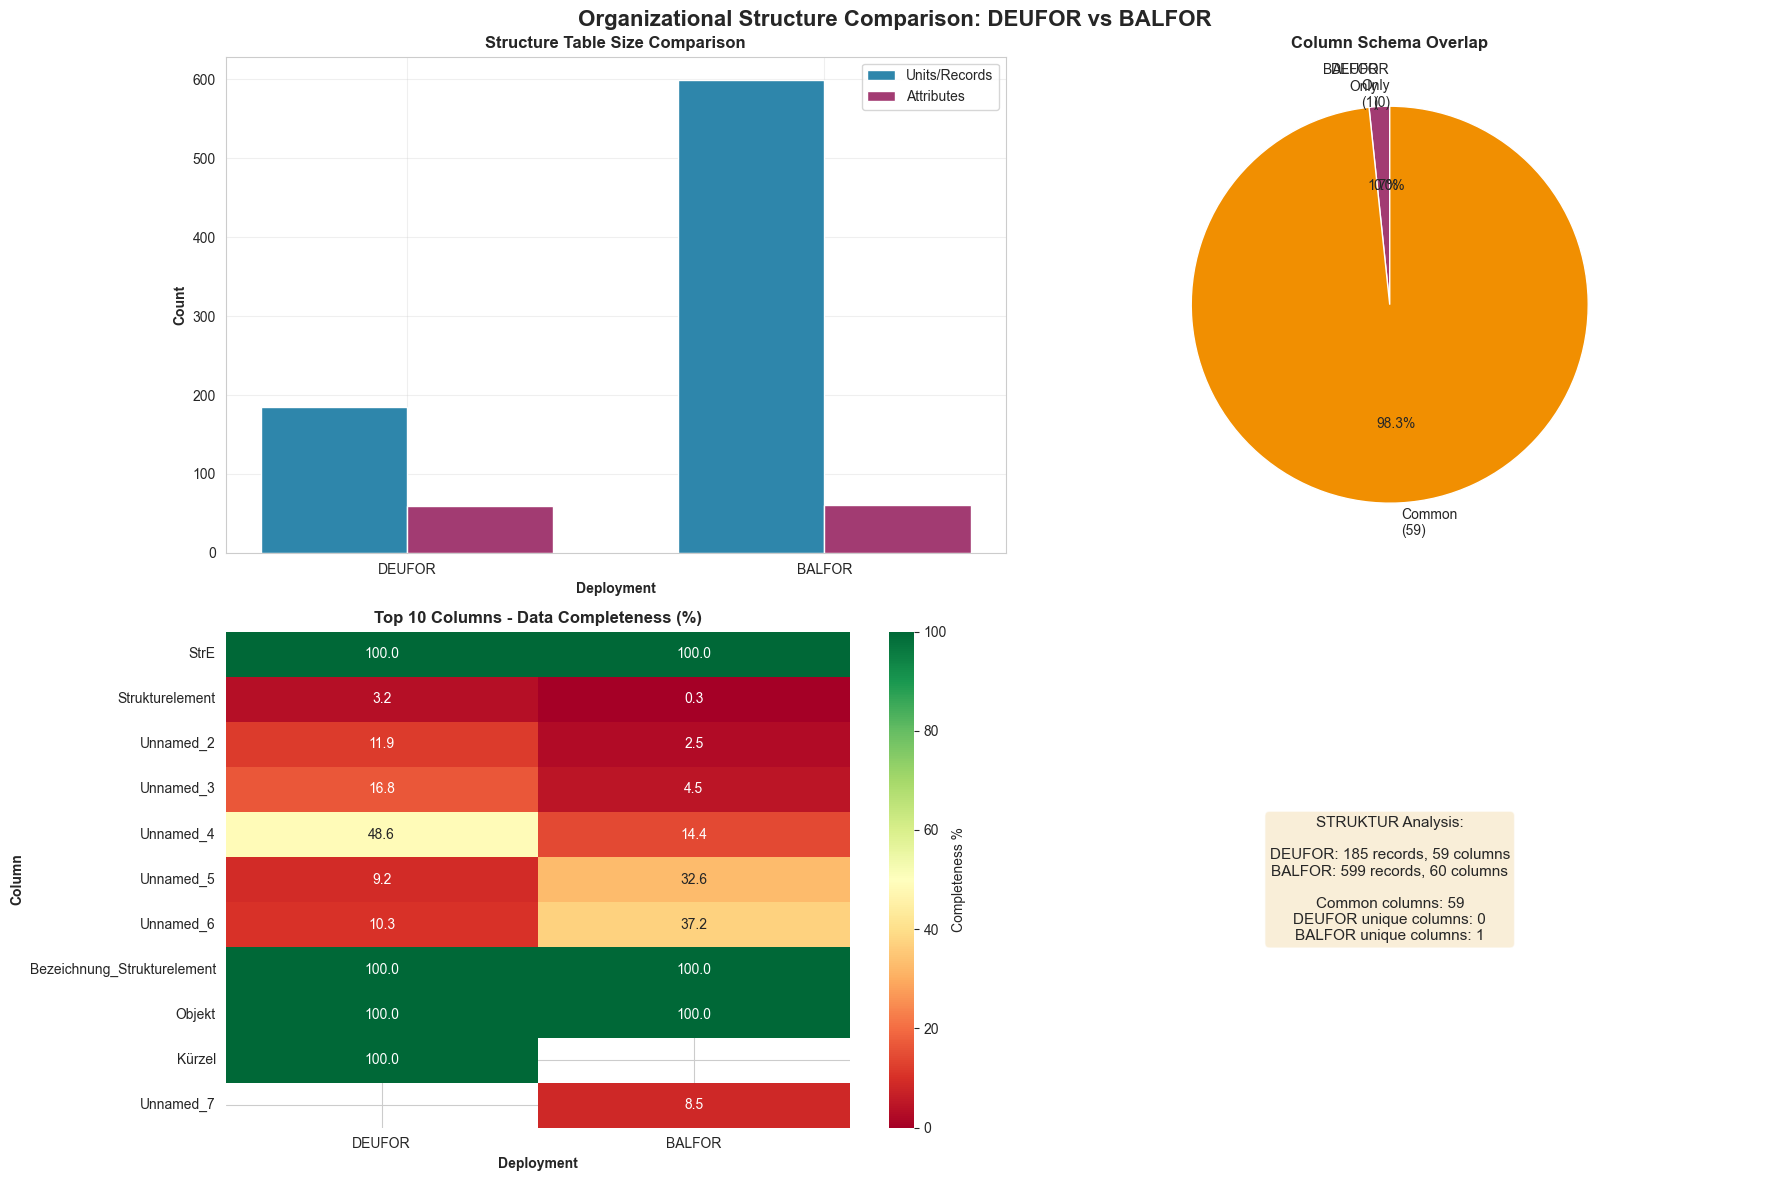


2. LOGISTICS/TRANSPORT POINTS COMPARISON (TP_STRUKTUREN)


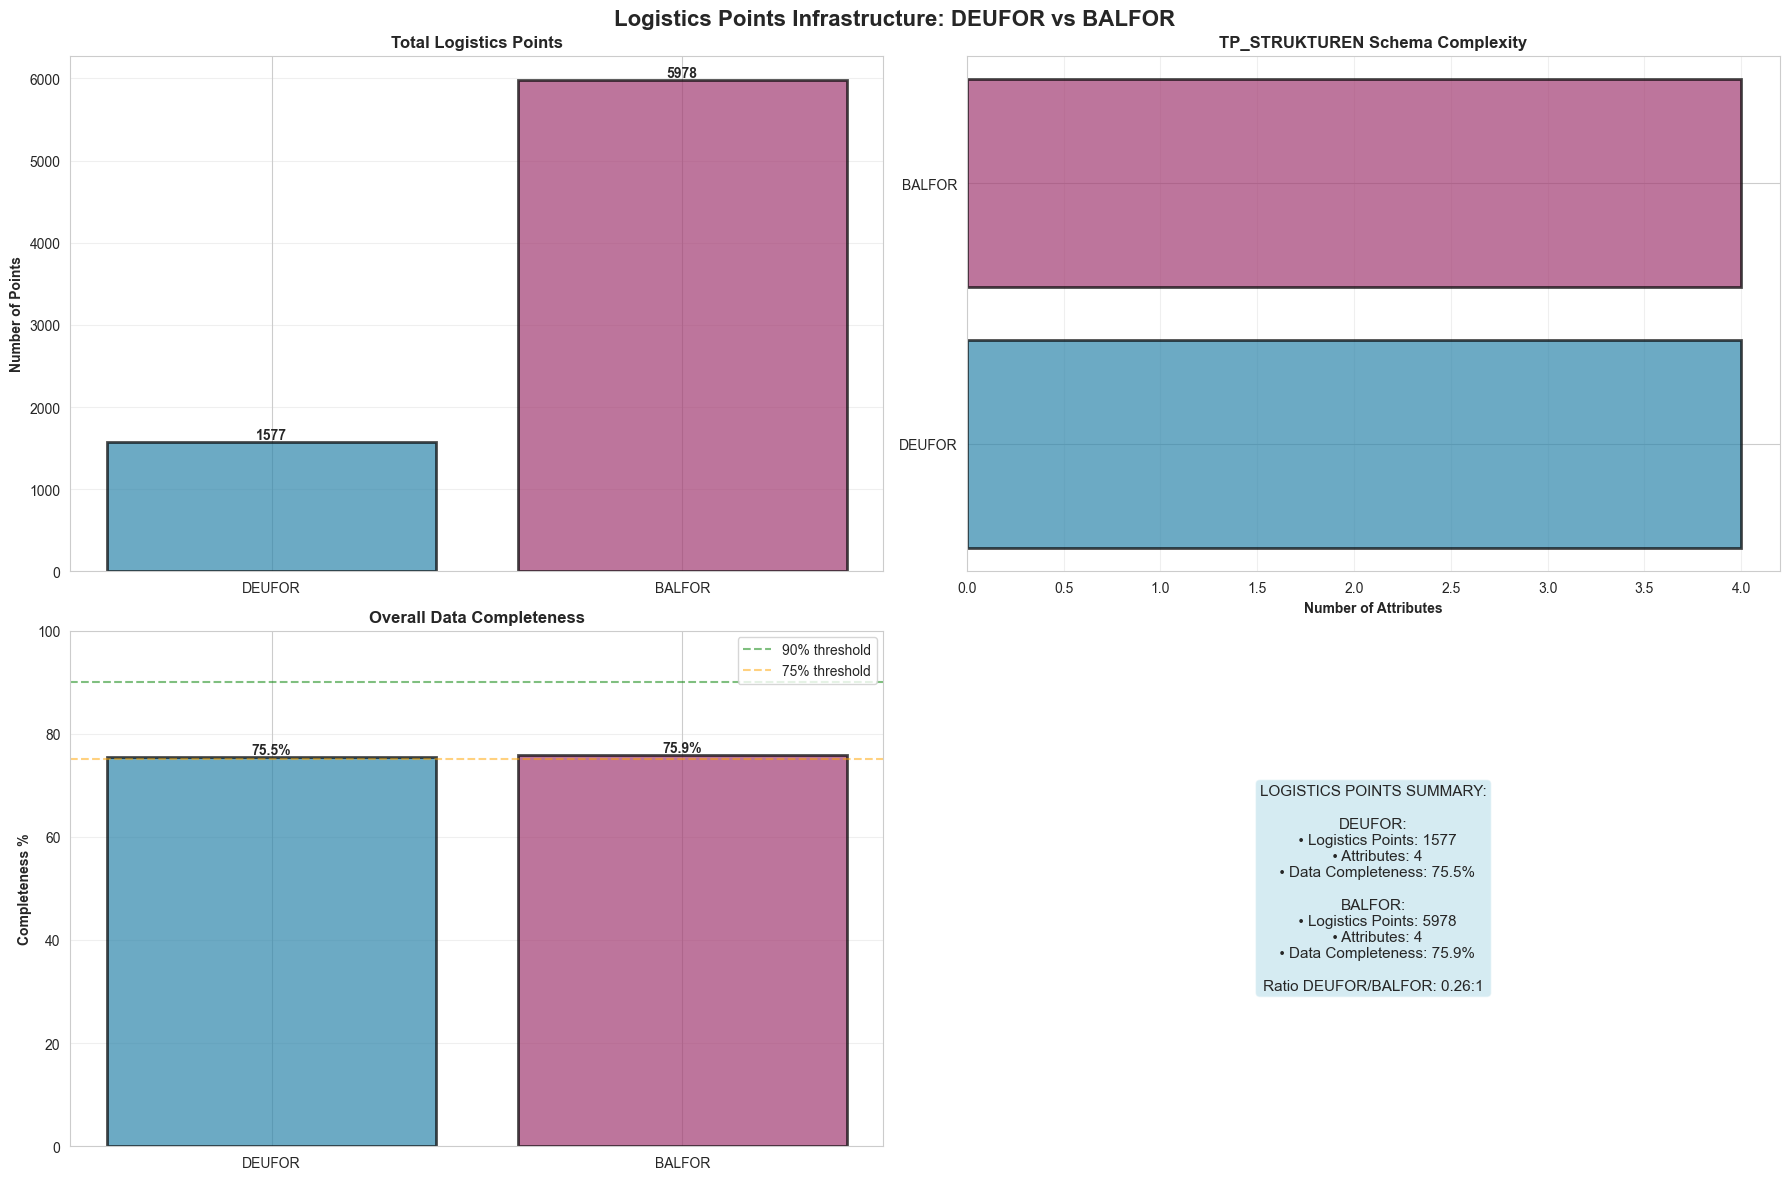


3. EQUIPMENT COMPARISON (EQ - Anlagevermögen/Fixed Assets)


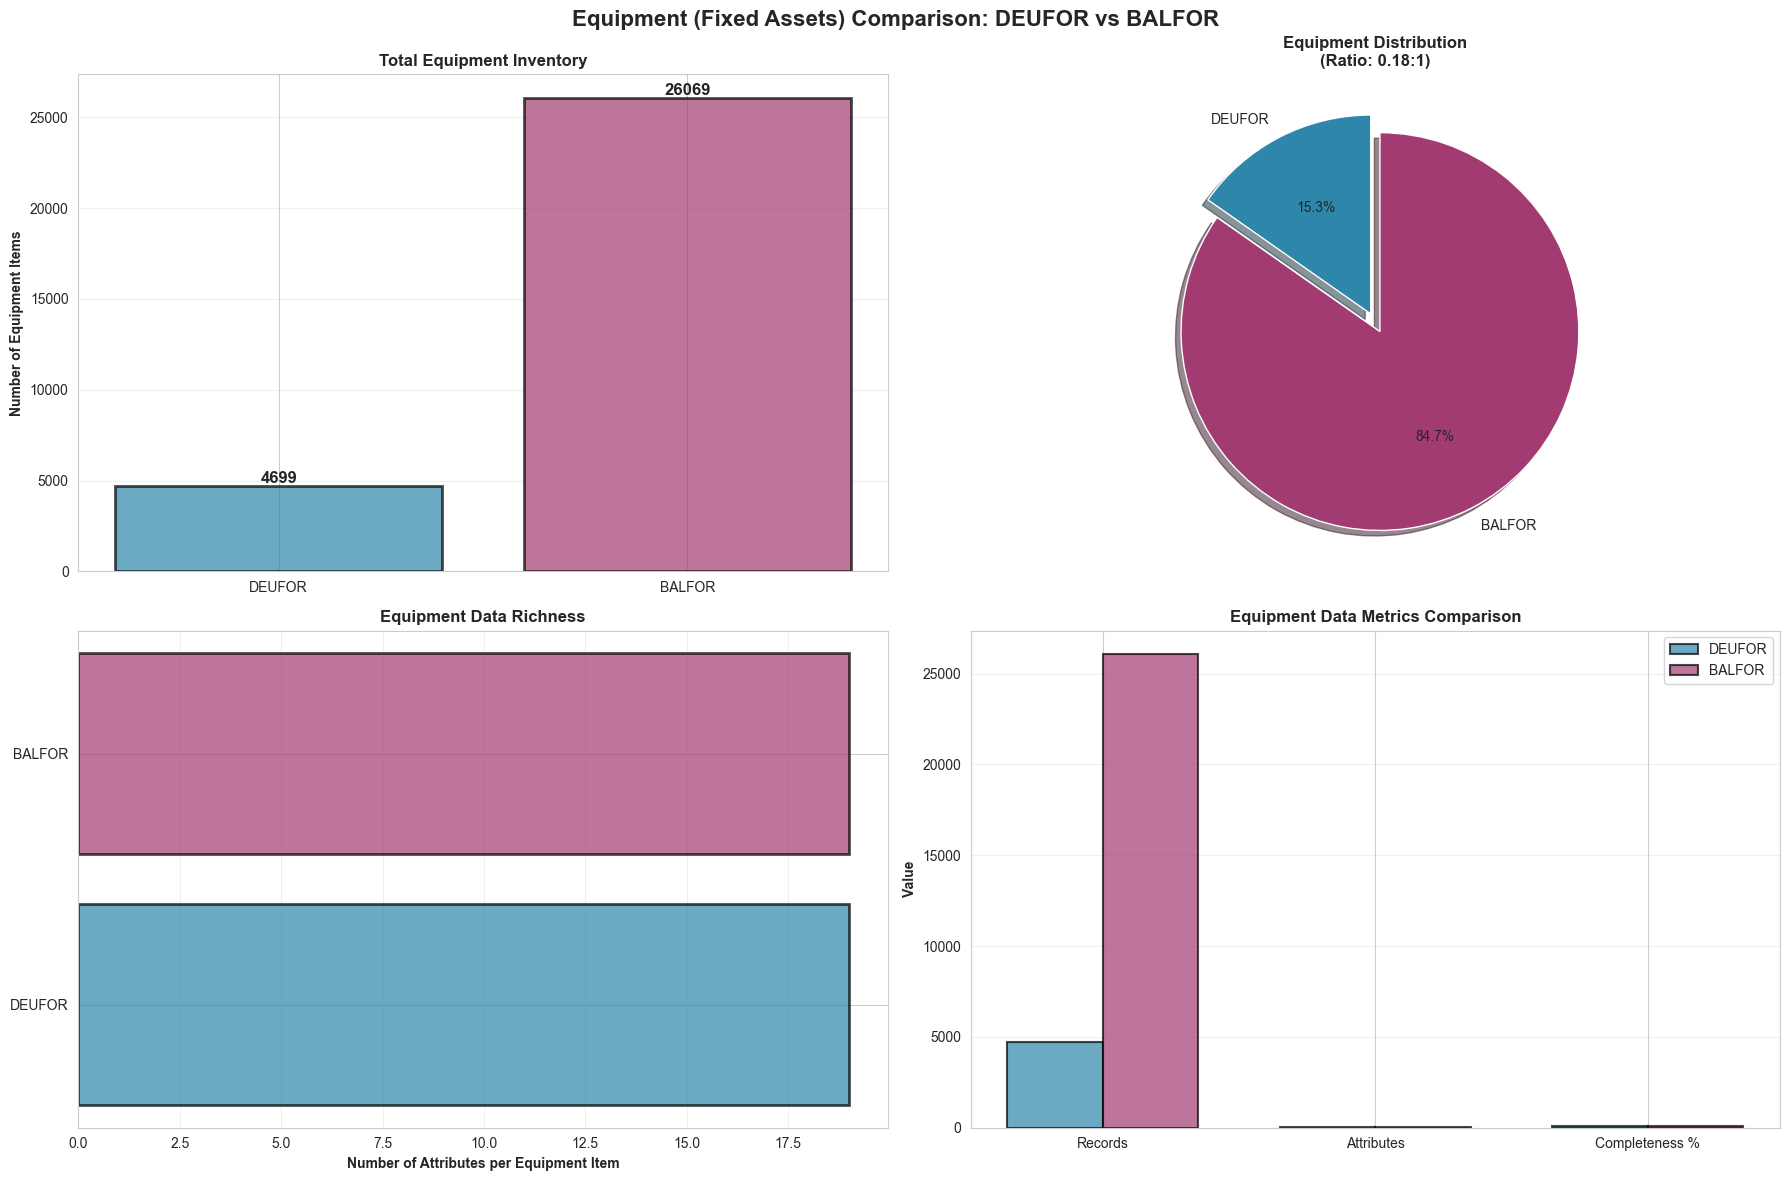


4. INVENTORY/STOCK COMPARISON (BESTAENDE - Umlaufvermögen/Current Assets)


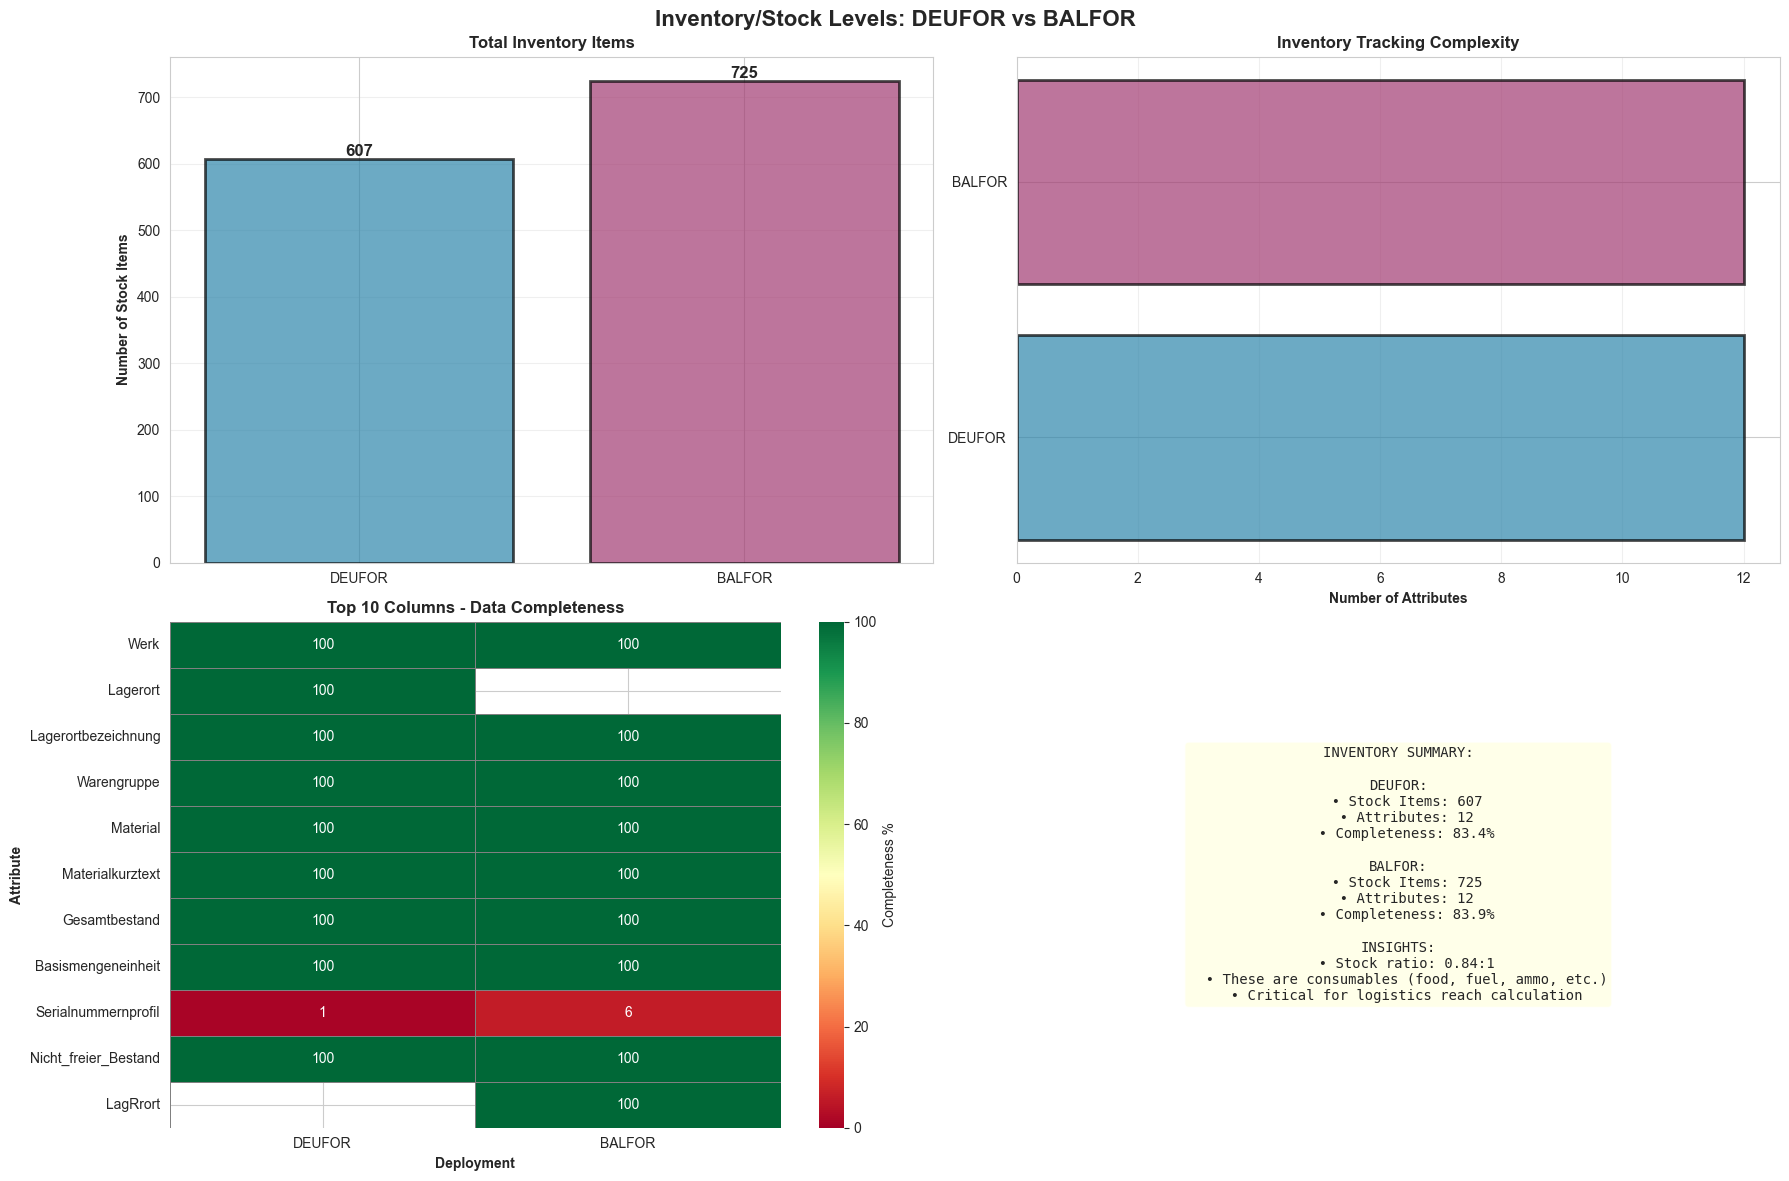


5. OVERALL DEPLOYMENT COMPARISON


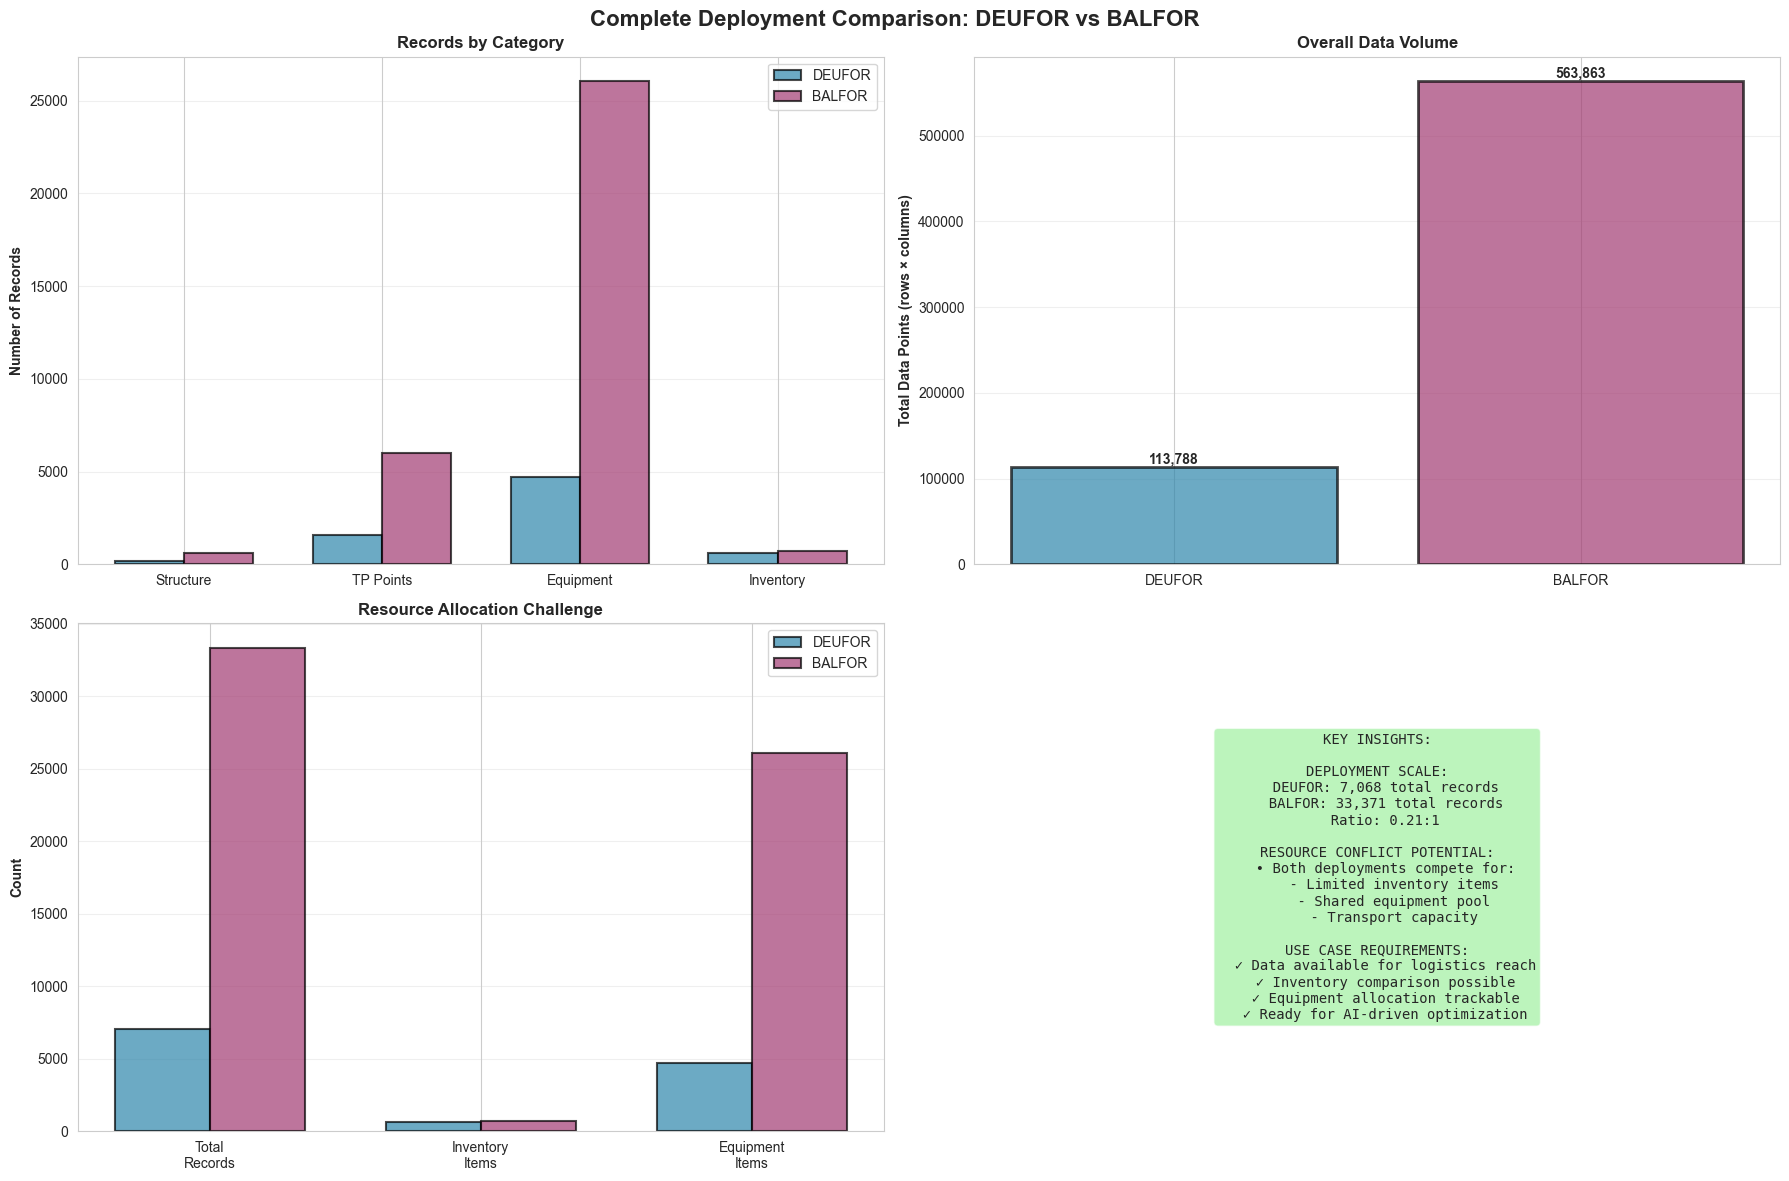


VISUALIZATION COMPLETE


In [7]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

print("="*80)
print("DATA VISUALIZATION ANALYSIS - German Military Logistics")
print("="*80)

# ============================================================================
# 1. ORGANIZATIONAL STRUCTURE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("1. ORGANIZATIONAL STRUCTURE COMPARISON (STRUKTUR)")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Organizational Structure Comparison: DEUFOR vs BALFOR', fontsize=16, fontweight='bold')

# Compare table sizes
if struktur_deufor is not None and struktur_balfor is not None:
    # Size comparison
    sizes = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Units/Records': [len(struktur_deufor), len(struktur_balfor)],
        'Attributes': [len(struktur_deufor.columns), len(struktur_balfor.columns)]
    })
    
    ax = axes[0, 0]
    x = np.arange(len(sizes))
    width = 0.35
    ax.bar(x - width/2, sizes['Units/Records'], width, label='Units/Records', color='#2E86AB')
    ax.bar(x + width/2, sizes['Attributes'], width, label='Attributes', color='#A23B72')
    ax.set_xlabel('Deployment', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Structure Table Size Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes['Deployment'])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Column overlap analysis
    ax = axes[0, 1]
    deufor_cols = set(struktur_deufor.columns)
    balfor_cols = set(struktur_balfor.columns)
    common_cols = deufor_cols & balfor_cols
    deufor_only = deufor_cols - balfor_cols
    balfor_only = balfor_cols - deufor_cols
    
    venn_data = [len(deufor_only), len(balfor_only), len(common_cols)]
    venn_labels = [f'DEUFOR\nOnly\n({len(deufor_only)})', 
                   f'BALFOR\nOnly\n({len(balfor_only)})', 
                   f'Common\n({len(common_cols)})']
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    ax.pie(venn_data, labels=venn_labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax.set_title('Column Schema Overlap', fontweight='bold')
    
    # Data completeness heatmap
    ax = axes[1, 0]
    completeness_data = []
    for name, df in [('DEUFOR', struktur_deufor), ('BALFOR', struktur_balfor)]:
        if df is not None and len(df) > 0:
            completeness = (1 - df.isnull().sum() / len(df)) * 100
            completeness_data.append(completeness.head(10))
    
    if completeness_data:
        completeness_df = pd.DataFrame(completeness_data, index=['DEUFOR', 'BALFOR']).T
        sns.heatmap(completeness_df, annot=True, fmt='.1f', cmap='RdYlGn', 
                   vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Completeness %'})
        ax.set_title('Top 10 Columns - Data Completeness (%)', fontweight='bold')
        ax.set_xlabel('Deployment', fontweight='bold')
        ax.set_ylabel('Column', fontweight='bold')
    
    # Record count comparison by category (if applicable column exists)
    ax = axes[1, 1]
    ax.text(0.5, 0.5, f'STRUKTUR Analysis:\n\n' +
            f'DEUFOR: {len(struktur_deufor)} records, {len(struktur_deufor.columns)} columns\n' +
            f'BALFOR: {len(struktur_balfor)} records, {len(struktur_balfor.columns)} columns\n\n' +
            f'Common columns: {len(common_cols)}\n' +
            f'DEUFOR unique columns: {len(deufor_only)}\n' +
            f'BALFOR unique columns: {len(balfor_only)}',
            ha='center', va='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# 2. LOGISTICS POINTS COMPARISON (TP_STRUKTUREN)
# ============================================================================
print("\n" + "="*80)
print("2. LOGISTICS/TRANSPORT POINTS COMPARISON (TP_STRUKTUREN)")
print("="*80)

if tp_strukturen_deufor is not None and tp_strukturen_balfor is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Logistics Points Infrastructure: DEUFOR vs BALFOR', fontsize=16, fontweight='bold')
    
    # Size comparison
    ax = axes[0, 0]
    tp_counts = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Logistics Points': [len(tp_strukturen_deufor), len(tp_strukturen_balfor)]
    })
    bars = ax.bar(tp_counts['Deployment'], tp_counts['Logistics Points'], 
                   color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Points', fontweight='bold')
    ax.set_title('Total Logistics Points', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    # Column structure comparison
    ax = axes[0, 1]
    tp_col_data = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Columns': [len(tp_strukturen_deufor.columns), len(tp_strukturen_balfor.columns)]
    })
    ax.barh(tp_col_data['Deployment'], tp_col_data['Columns'], 
            color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('Number of Attributes', fontweight='bold')
    ax.set_title('TP_STRUKTUREN Schema Complexity', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Data quality comparison
    ax = axes[1, 0]
    quality_deufor = (1 - tp_strukturen_deufor.isnull().sum().sum() / (len(tp_strukturen_deufor) * len(tp_strukturen_deufor.columns))) * 100
    quality_balfor = (1 - tp_strukturen_balfor.isnull().sum().sum() / (len(tp_strukturen_balfor) * len(tp_strukturen_balfor.columns))) * 100
    
    quality_data = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Completeness %': [quality_deufor, quality_balfor]
    })
    bars = ax.bar(quality_data['Deployment'], quality_data['Completeness %'], 
                   color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Completeness %', fontweight='bold')
    ax.set_title('Overall Data Completeness', fontweight='bold')
    ax.set_ylim([0, 100])
    ax.axhline(y=90, color='green', linestyle='--', label='90% threshold', alpha=0.5)
    ax.axhline(y=75, color='orange', linestyle='--', label='75% threshold', alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontweight='bold')
    
    # Summary
    ax = axes[1, 1]
    summary_text = f'LOGISTICS POINTS SUMMARY:\n\n' + \
                   f'DEUFOR:\n' + \
                   f'  • Logistics Points: {len(tp_strukturen_deufor)}\n' + \
                   f'  • Attributes: {len(tp_strukturen_deufor.columns)}\n' + \
                   f'  • Data Completeness: {quality_deufor:.1f}%\n\n' + \
                   f'BALFOR:\n' + \
                   f'  • Logistics Points: {len(tp_strukturen_balfor)}\n' + \
                   f'  • Attributes: {len(tp_strukturen_balfor.columns)}\n' + \
                   f'  • Data Completeness: {quality_balfor:.1f}%\n\n' + \
                   f'Ratio DEUFOR/BALFOR: {len(tp_strukturen_deufor)/len(tp_strukturen_balfor):.2f}:1'
    
    ax.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 3. EQUIPMENT COMPARISON (EQ - Fixed Assets)
# ============================================================================
print("\n" + "="*80)
print("3. EQUIPMENT COMPARISON (EQ - Anlagevermögen/Fixed Assets)")
print("="*80)

if eq_deufor is not None and eq_balfor is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Equipment (Fixed Assets) Comparison: DEUFOR vs BALFOR', fontsize=16, fontweight='bold')
    
    # Equipment count comparison
    ax = axes[0, 0]
    eq_counts = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Equipment Items': [len(eq_deufor), len(eq_balfor)]
    })
    bars = ax.bar(eq_counts['Deployment'], eq_counts['Equipment Items'],
                   color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Equipment Items', fontweight='bold')
    ax.set_title('Total Equipment Inventory', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Ratio visualization
    ax = axes[0, 1]
    ratio = len(eq_deufor) / len(eq_balfor) if len(eq_balfor) > 0 else 0
    sizes = [len(eq_deufor), len(eq_balfor)]
    colors = ['#2E86AB', '#A23B72']
    explode = (0.05, 0.05)
    
    ax.pie(sizes, explode=explode, labels=['DEUFOR', 'BALFOR'], autopct='%1.1f%%',
           colors=colors, shadow=True, startangle=90)
    ax.set_title(f'Equipment Distribution\n(Ratio: {ratio:.2f}:1)', fontweight='bold')
    
    # Data density (columns per deployment)
    ax = axes[1, 0]
    attributes = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Attributes': [len(eq_deufor.columns), len(eq_balfor.columns)]
    })
    ax.barh(attributes['Deployment'], attributes['Attributes'],
            color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('Number of Attributes per Equipment Item', fontweight='bold')
    ax.set_title('Equipment Data Richness', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Completeness comparison
    ax = axes[1, 1]
    missing_deufor = eq_deufor.isnull().sum().sum()
    missing_balfor = eq_balfor.isnull().sum().sum()
    total_deufor = len(eq_deufor) * len(eq_deufor.columns)
    total_balfor = len(eq_balfor) * len(eq_balfor.columns)
    
    completeness_deufor = (1 - missing_deufor / total_deufor) * 100 if total_deufor > 0 else 0
    completeness_balfor = (1 - missing_balfor / total_balfor) * 100 if total_balfor > 0 else 0
    
    metrics = pd.DataFrame({
        'Metric': ['Records', 'Attributes', 'Completeness %'],
        'DEUFOR': [len(eq_deufor), len(eq_deufor.columns), completeness_deufor],
        'BALFOR': [len(eq_balfor), len(eq_balfor.columns), completeness_balfor]
    })
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, metrics['DEUFOR'], width, label='DEUFOR', 
                    color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, metrics['BALFOR'], width, label='BALFOR',
                    color='#A23B72', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Value', fontweight='bold')
    ax.set_title('Equipment Data Metrics Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics['Metric'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. INVENTORY/STOCK COMPARISON (BESTAENDE - Current Assets)
# ============================================================================
print("\n" + "="*80)
print("4. INVENTORY/STOCK COMPARISON (BESTAENDE - Umlaufvermögen/Current Assets)")
print("="*80)

if bestaende_deufor is not None and bestaende_balfor is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Inventory/Stock Levels: DEUFOR vs BALFOR', fontsize=16, fontweight='bold')
    
    # Stock items count
    ax = axes[0, 0]
    stock_counts = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Stock Items': [len(bestaende_deufor), len(bestaende_balfor)]
    })
    bars = ax.bar(stock_counts['Deployment'], stock_counts['Stock Items'],
                   color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Stock Items', fontweight='bold')
    ax.set_title('Total Inventory Items', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Inventory complexity (attributes tracked per item)
    ax = axes[0, 1]
    complexity = pd.DataFrame({
        'Deployment': ['DEUFOR', 'BALFOR'],
        'Tracked Attributes': [len(bestaende_deufor.columns), len(bestaende_balfor.columns)]
    })
    bars = ax.barh(complexity['Deployment'], complexity['Tracked Attributes'],
                    color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xlabel('Number of Attributes', fontweight='bold')
    ax.set_title('Inventory Tracking Complexity', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Data quality heatmap (top columns)
    ax = axes[1, 0]
    quality_comparison = []
    for name, df in [('DEUFOR', bestaende_deufor), ('BALFOR', bestaende_balfor)]:
        if df is not None and len(df) > 0:
            completeness = (1 - df.isnull().sum() / len(df)) * 100
            quality_comparison.append(completeness.head(10))
    
    if quality_comparison:
        quality_df = pd.DataFrame(quality_comparison, index=['DEUFOR', 'BALFOR']).T
        sns.heatmap(quality_df, annot=True, fmt='.0f', cmap='RdYlGn',
                   vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Completeness %'},
                   linewidths=0.5, linecolor='gray')
        ax.set_title('Top 10 Columns - Data Completeness', fontweight='bold')
        ax.set_xlabel('Deployment', fontweight='bold')
        ax.set_ylabel('Attribute', fontweight='bold')
    
    # Overall summary
    ax = axes[1, 1]
    overall_deufor = (1 - bestaende_deufor.isnull().sum().sum() / (len(bestaende_deufor) * len(bestaende_deufor.columns))) * 100
    overall_balfor = (1 - bestaende_balfor.isnull().sum().sum() / (len(bestaende_balfor) * len(bestaende_balfor.columns))) * 100
    
    summary = f'INVENTORY SUMMARY:\n\n' + \
              f'DEUFOR:\n' + \
              f'  • Stock Items: {len(bestaende_deufor):,}\n' + \
              f'  • Attributes: {len(bestaende_deufor.columns)}\n' + \
              f'  • Completeness: {overall_deufor:.1f}%\n\n' + \
              f'BALFOR:\n' + \
              f'  • Stock Items: {len(bestaende_balfor):,}\n' + \
              f'  • Attributes: {len(bestaende_balfor.columns)}\n' + \
              f'  • Completeness: {overall_balfor:.1f}%\n\n' + \
              f'INSIGHTS:\n' + \
              f'  • Stock ratio: {len(bestaende_deufor)/len(bestaende_balfor):.2f}:1\n' + \
              f'  • These are consumables (food, fuel, ammo, etc.)\n' + \
              f'  • Critical for logistics reach calculation'
    
    ax.text(0.5, 0.5, summary, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7),
            family='monospace')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 5. OVERALL DEPLOYMENT COMPARISON
# ============================================================================
print("\n" + "="*80)
print("5. OVERALL DEPLOYMENT COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Complete Deployment Comparison: DEUFOR vs BALFOR', fontsize=16, fontweight='bold')

# Total records across all tables
ax = axes[0, 0]
categories = ['Structure', 'TP Points', 'Equipment', 'Inventory']
deufor_counts = [
    len(struktur_deufor) if struktur_deufor is not None else 0,
    len(tp_strukturen_deufor) if tp_strukturen_deufor is not None else 0,
    len(eq_deufor) if eq_deufor is not None else 0,
    len(bestaende_deufor) if bestaende_deufor is not None else 0
]
balfor_counts = [
    len(struktur_balfor) if struktur_balfor is not None else 0,
    len(tp_strukturen_balfor) if tp_strukturen_balfor is not None else 0,
    len(eq_balfor) if eq_balfor is not None else 0,
    len(bestaende_balfor) if bestaende_balfor is not None else 0
]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, deufor_counts, width, label='DEUFOR',
                color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, balfor_counts, width, label='BALFOR',
                color='#A23B72', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Number of Records', fontweight='bold')
ax.set_title('Records by Category', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Data volume (total cells)
ax = axes[0, 1]
deufor_total = sum([
    len(df) * len(df.columns) if df is not None else 0
    for df in [struktur_deufor, tp_strukturen_deufor, eq_deufor, bestaende_deufor]
])
balfor_total = sum([
    len(df) * len(df.columns) if df is not None else 0
    for df in [struktur_balfor, tp_strukturen_balfor, eq_balfor, bestaende_balfor]
])

volumes = pd.DataFrame({
    'Deployment': ['DEUFOR', 'BALFOR'],
    'Total Data Points': [deufor_total, balfor_total]
})
bars = ax.bar(volumes['Deployment'], volumes['Total Data Points'],
               color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Total Data Points (rows × columns)', fontweight='bold')
ax.set_title('Overall Data Volume', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold')

# Resource allocation challenge
ax = axes[1, 0]
total_deufor_records = sum(deufor_counts)
total_balfor_records = sum(balfor_counts)

challenge_data = pd.DataFrame({
    'Category': ['Total\nRecords', 'Inventory\nItems', 'Equipment\nItems'],
    'DEUFOR': [total_deufor_records, deufor_counts[3], deufor_counts[2]],
    'BALFOR': [total_balfor_records, balfor_counts[3], balfor_counts[2]]
})

x = np.arange(len(challenge_data))
width = 0.35

bars1 = ax.bar(x - width/2, challenge_data['DEUFOR'], width, label='DEUFOR',
                color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, challenge_data['BALFOR'], width, label='BALFOR',
                color='#A23B72', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Resource Allocation Challenge', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(challenge_data['Category'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Key insights
ax = axes[1, 1]
insights = f'KEY INSIGHTS:\n\n' + \
           f'DEPLOYMENT SCALE:\n' + \
           f'  DEUFOR: {total_deufor_records:,} total records\n' + \
           f'  BALFOR: {total_balfor_records:,} total records\n' + \
           f'  Ratio: {total_deufor_records/total_balfor_records:.2f}:1\n\n' + \
           f'RESOURCE CONFLICT POTENTIAL:\n' + \
           f'  • Both deployments compete for:\n' + \
           f'    - Limited inventory items\n' + \
           f'    - Shared equipment pool\n' + \
           f'    - Transport capacity\n\n' + \
           f'USE CASE REQUIREMENTS:\n' + \
           f'  ✓ Data available for logistics reach\n' + \
           f'  ✓ Inventory comparison possible\n' + \
           f'  ✓ Equipment allocation trackable\n' + \
           f'  ✓ Ready for AI-driven optimization'

ax.text(0.5, 0.5, insights, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6),
        family='monospace')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)


EQUIPMENT ANALYSIS (EQ - Fixed Assets) & ORGANIZATIONAL STRUCTURE - Force Elements


/var/folders/sn/2m3912k50xsds2npt6lxymjh0000gn/T/ipykernel_98603/1019294663.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


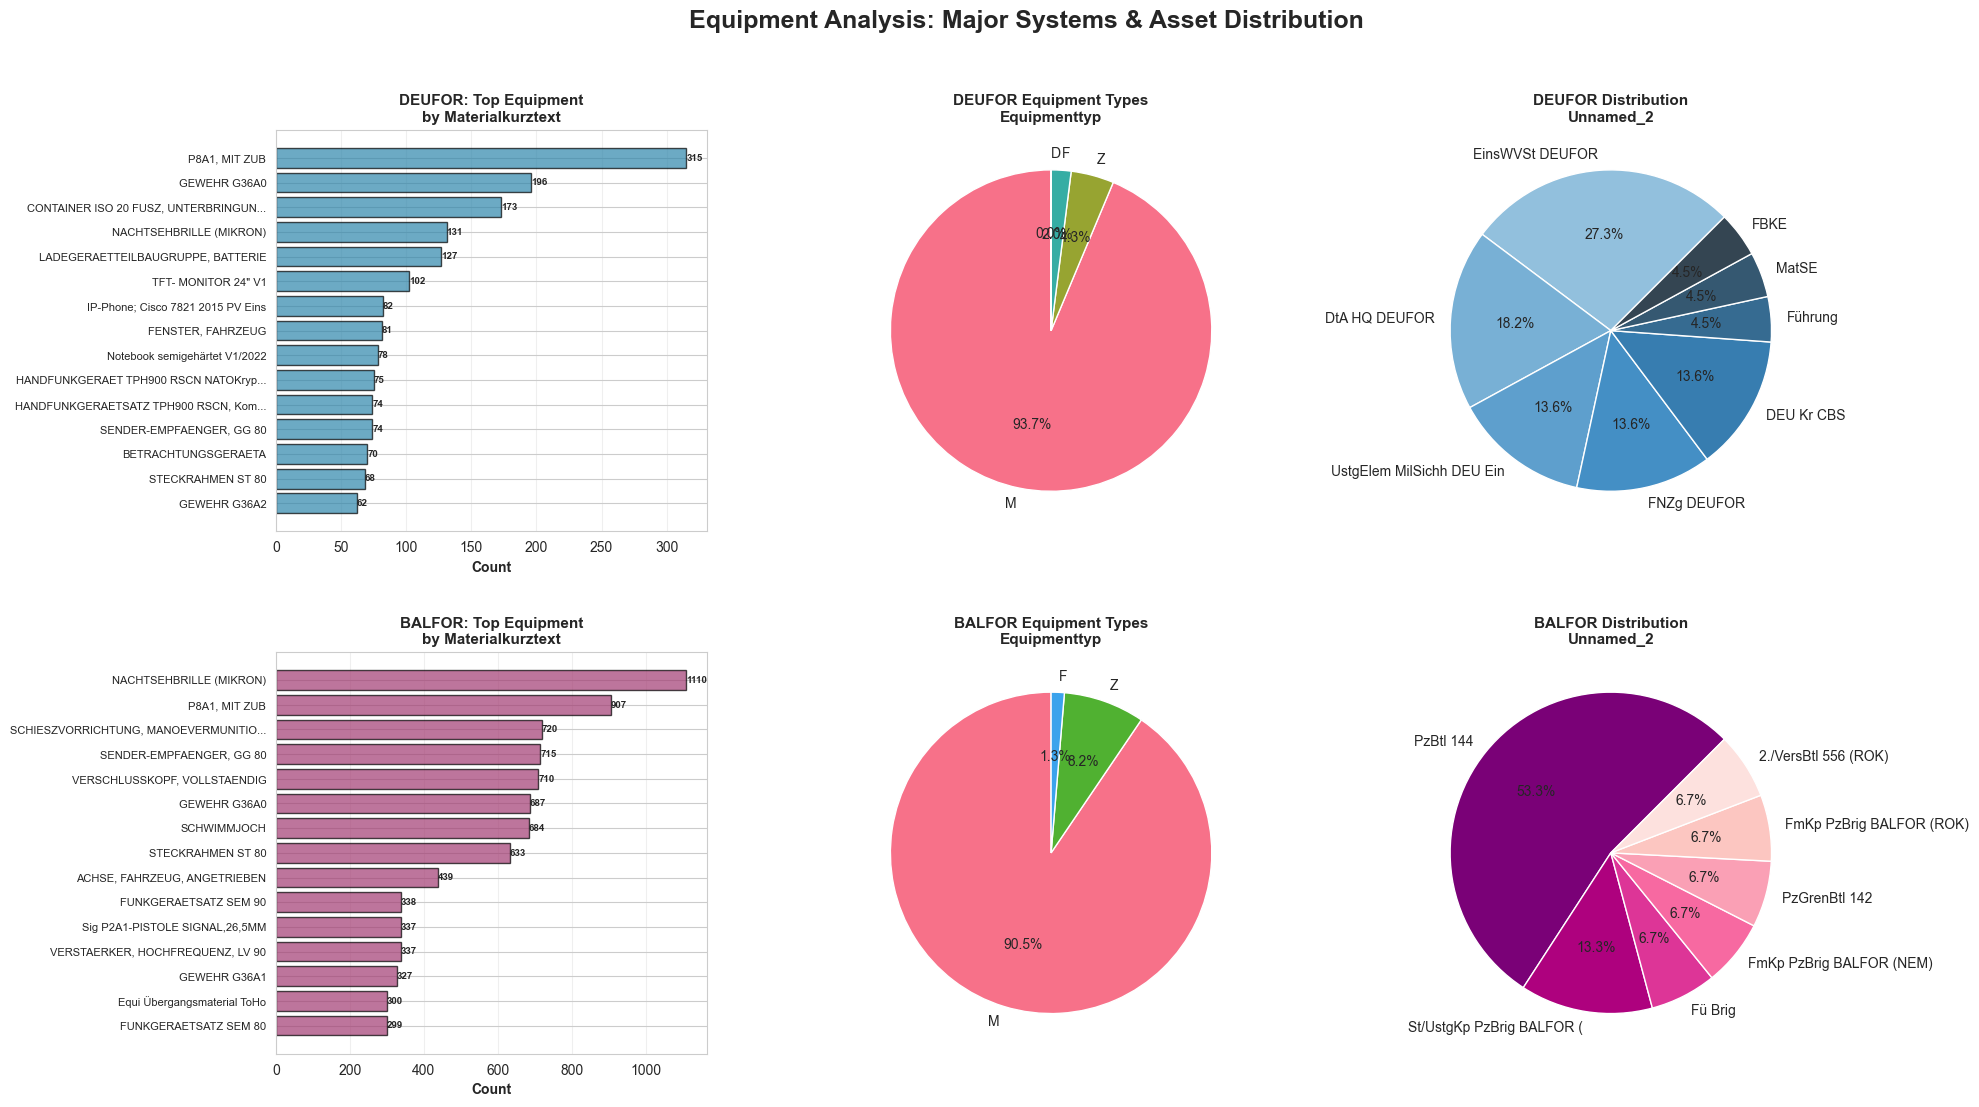

In [8]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ============================================================================
# 1. EQUIPMENT ANALYSIS - Critical Assets
# ============================================================================
print("\n" + "="*90)
print("EQUIPMENT ANALYSIS (EQ - Fixed Assets) & ORGANIZATIONAL STRUCTURE - Force Elements")
print("="*90)

if eq_deufor is not None and eq_balfor is not None:
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    fig.suptitle('Equipment Analysis: Major Systems & Asset Distribution', fontsize=18, fontweight='bold', y=0.98)
    
    # Analyze categorical columns for equipment types
    eq_deufor_cat_cols = eq_deufor.select_dtypes(include=['object']).columns.tolist()
    eq_balfor_cat_cols = eq_balfor.select_dtypes(include=['object']).columns.tolist()
    
    # Top equipment categories DEUFOR
    if len(eq_deufor_cat_cols) > 0:
        ax = fig.add_subplot(gs[0, 0])
        cat_col = eq_deufor_cat_cols[0]
        
        top_categories = eq_deufor[cat_col].value_counts().head(15)
        
        bars = ax.barh(range(len(top_categories)), top_categories.values, 
                      color='#2E86AB', alpha=0.7, edgecolor='black')
        ax.set_yticks(range(len(top_categories)))
        ax.set_yticklabels([label[:35] + '...' if len(str(label)) > 35 else str(label) 
                           for label in top_categories.index], fontsize=8)
        ax.set_xlabel('Count', fontweight='bold')
        ax.set_title(f'DEUFOR: Top Equipment\nby {cat_col[:20]}', fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.3, axis='x')
        ax.invert_yaxis()
        
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2., 
                   f'{int(width)}',
                   ha='left', va='center', fontsize=7, fontweight='bold')
    
    # Equipment diversity pie chart DEUFOR
    if len(eq_deufor_cat_cols) > 1:
        ax = fig.add_subplot(gs[0, 1])
        cat_col = eq_deufor_cat_cols[1] if len(eq_deufor_cat_cols) > 1 else eq_deufor_cat_cols[0]
        
        top_cats = eq_deufor[cat_col].value_counts().head(8)
        other_count = eq_deufor[cat_col].value_counts().iloc[8:].sum() if len(eq_deufor[cat_col].value_counts()) > 8 else 0
        
        if other_count > 0:
            top_cats['Other'] = other_count
        
        colors = sns.color_palette("husl", len(top_cats))
        ax.pie(top_cats.values, labels=[str(l)[:20] for l in top_cats.index], 
              autopct='%1.1f%%', colors=colors, startangle=90)
        ax.set_title(f'DEUFOR Equipment Types\n{cat_col[:20]}', fontweight='bold', fontsize=11)

    struct_deufor_cat = struktur_deufor.select_dtypes(include=['object']).columns.tolist()
    struct_balfor_cat = struktur_balfor.select_dtypes(include=['object']).columns.tolist()
    
    # Secondary categorization DEUFOR
    if len(struct_deufor_cat) > 1:
        ax = fig.add_subplot(gs[0, 2])
        cat_col = struct_deufor_cat[1]
        
        top_units = struktur_deufor[cat_col].value_counts().head(10)
        
        colors = sns.color_palette("Blues_d", len(top_units))
        ax.pie(top_units.values, labels=[str(l)[:25] for l in top_units.index],
              autopct='%1.1f%%', colors=colors, startangle=45)
        ax.set_title(f'DEUFOR Distribution\n{cat_col[:25]}', fontweight='bold', fontsize=11)
    
    # BALFOR equipment categories
    if len(eq_balfor_cat_cols) > 0:
        ax = fig.add_subplot(gs[1, 0])
        cat_col = eq_balfor_cat_cols[0]
        
        top_categories = eq_balfor[cat_col].value_counts().head(15)
        
        bars = ax.barh(range(len(top_categories)), top_categories.values, 
                      color='#A23B72', alpha=0.7, edgecolor='black')
        ax.set_yticks(range(len(top_categories)))
        ax.set_yticklabels([label[:35] + '...' if len(str(label)) > 35 else str(label) 
                           for label in top_categories.index], fontsize=8)
        ax.set_xlabel('Count', fontweight='bold')
        ax.set_title(f'BALFOR: Top Equipment\nby {cat_col[:20]}', fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.3, axis='x')
        ax.invert_yaxis()
        
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2., 
                   f'{int(width)}',
                   ha='left', va='center', fontsize=7, fontweight='bold')
    
    # BALFOR equipment diversity
    if len(eq_balfor_cat_cols) > 1:
        ax = fig.add_subplot(gs[1, 1])
        cat_col = eq_balfor_cat_cols[1] if len(eq_balfor_cat_cols) > 1 else eq_balfor_cat_cols[0]
        
        top_cats = eq_balfor[cat_col].value_counts().head(8)
        other_count = eq_balfor[cat_col].value_counts().iloc[8:].sum() if len(eq_balfor[cat_col].value_counts()) > 8 else 0
        
        if other_count > 0:
            top_cats['Other'] = other_count
        
        colors = sns.color_palette("husl", len(top_cats))
        ax.pie(top_cats.values, labels=[str(l)[:20] for l in top_cats.index], 
              autopct='%1.1f%%', colors=colors, startangle=90)
        ax.set_title(f'BALFOR Equipment Types\n{cat_col[:20]}', fontweight='bold', fontsize=11)
    
    if len(struct_balfor_cat) > 1:
        ax = fig.add_subplot(gs[1, 2])
        cat_col = struct_balfor_cat[1]
        
        top_units = struktur_balfor[cat_col].value_counts().head(10)
        
        colors = sns.color_palette("RdPu_r", len(top_units))
        ax.pie(top_units.values, labels=[str(l)[:25] for l in top_units.index],
              autopct='%1.1f%%', colors=colors, startangle=45)
        ax.set_title(f'BALFOR Distribution\n{cat_col[:25]}', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()